# Final Project - Vinny Casilio

The goal of this project is to create a relational database consisting of Housing Price Index data from 1991 to present, mortgage rates, construction inputs, and bank failures. The end user will be able to query the RDB to determine if any correlation exists between the different data sets.

## Sources of the data

All data was acquired through various federal sources, see links below:

Housing Price Index: https://www.fhfa.gov/data/hpi/datasets

Bank failures: https://banks.data.fdic.gov/bankfind-suite/failures

Mortgage rates: https://www.freddiemac.com/pmms

Cement prices: https://fred.stlouisfed.org/series/PCU32733273

Steel prices: https://fred.stlouisfed.org/series/WPU1017

Copper prices: https://fred.stlouisfed.org/series/WPUSIO19011

Lumber prices: https://fred.stlouisfed.org/series/WPU08

Labor salory: https://fred.stlouisfed.org/series/CXUHOUSINGLB1207M




# Extract


In [300]:
#import modules
import pandas as pd
import numpy as np
np.set_printoptions(legacy='1.25')
import datetime
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"


## Load raw data


In [301]:
# load files from S3 bucket on AWS
hpi_og = pd.read_csv('https://ista322-su25-hw5-vinny-casilio.s3.us-east-2.amazonaws.com/hpi_master.csv')
bank_fails_og = pd.read_csv('https://ista322-su25-hw5-vinny-casilio.s3.us-east-2.amazonaws.com/bank_failures.csv')
mortgage_rates_og = pd.read_excel('https://ista322-su25-hw5-vinny-casilio.s3.us-east-2.amazonaws.com/mortgage_rates.xlsx', skiprows=4, header = None, skipfooter=1)
concrete_og = pd.read_csv('https://ista322-su25-hw5-vinny-casilio.s3.us-east-2.amazonaws.com/concrete.csv')
steel_og = pd.read_csv('https://ista322-su25-hw5-vinny-casilio.s3.us-east-2.amazonaws.com/steel.csv')
copper_og = pd.read_csv('https://ista322-su25-hw5-vinny-casilio.s3.us-east-2.amazonaws.com/copper.csv')
lumber_og = pd.read_csv('https://ista322-su25-hw5-vinny-casilio.s3.us-east-2.amazonaws.com/lumber.csv')
labor_og = pd.read_csv('https://ista322-su25-hw5-vinny-casilio.s3.us-east-2.amazonaws.com/housing_labor_costs.csv')

### Explore Housing price index

This will be the main table and will need to be cleaned and processed to be usable


In [302]:
#shape, columns, and full df of housing price index
hpi_og.shape
hpi_og.columns
hpi_og

(130697, 10)

Index(['hpi_type', 'hpi_flavor', 'frequency', 'level', 'place_name',
       'place_id', 'yr', 'period', 'index_nsa', 'index_sa'],
      dtype='object')

,hpi_type,hpi_flavor,frequency,level,place_name,place_id,yr,period,index_nsa,index_sa
0,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,1,100.00,100.00
1,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,2,100.87,100.87
2,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,3,101.32,100.90
3,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,4,101.73,100.97
4,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,5,102.32,101.30
...,...,...,...,...,...,...,...,...,...,...
130692,developmental,purchase-only,quarterly,Puerto Rico,Puerto Rico,PR,2024,1,201.68,204.83
130693,developmental,purchase-only,quarterly,Puerto Rico,Puerto Rico,PR,2024,2,224.54,222.68
130694,developmental,purchase-only,quarterly,Puerto Rico,Puerto Rico,PR,2024,3,233.53,226.83
130695,developmental,purchase-only,quarterly,Puerto Rico,Puerto Rico,PR,2024,4,229.51,236.17


### Explore mortgage rate data

In [303]:
#shape, columns, and full df of mortgage rates
mortgage_rates_og.shape
mortgage_rates_og.columns
mortgage_rates_og

(2841, 9)

Index([0, 1, 2, 3, 4, 5, 6, 7, 8], dtype='int64')

,0,1,2,3,4,5,6,7,8
0,NaN,U.S.,30 yr,U.S.,15 yr,U.S.,5/1 ARM,U.S.,30 yr FRM/
1,NaN,30 yr,fees &,15 yr,fees &,5/1,fees &,5/1 ARM,5/1 ARM
2,Week,FRM,points,FRM,points,ARM,points,margin,spread
3,1971-04-02 00:00:00,7.33,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1971-04-09 00:00:00,7.31,,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2836,2025-07-17 00:00:00,6.75,NaN,5.92,NaN,NaN,NaN,NaN,NaN
2837,2025-07-24 00:00:00,6.74,NaN,5.87,NaN,NaN,NaN,NaN,NaN
2838,2025-07-31 00:00:00,6.72,NaN,5.85,NaN,NaN,NaN,NaN,NaN
2839,2025-08-07 00:00:00,6.63,NaN,5.75,NaN,NaN,NaN,NaN,NaN


### Explore Bank Failures

In [304]:
#shape, columns, and full df of bank failures
bank_fails_og.shape
bank_fails_og.columns
bank_fails_og

(1132, 13)

Index(['CERT', 'CHCLASS1', 'CITYST', 'COST', 'FAILDATE', 'FIN', 'ID', 'NAME',
       'QBFASSET', 'QBFDEP', 'RESTYPE', 'RESTYPE1', 'SAVR'],
      dtype='object')

,CERT,CHCLASS1,CITYST,COST,FAILDATE,FIN,ID,NAME,QBFASSET,QBFDEP,RESTYPE,RESTYPE1,SAVR
0,28634,SL,"RANDALLSTOWN, MD",2.0,1/4/1991,7266,2981,ROYAL OAK FS & LA,27310,29154,FAILURE,PA,RTC
1,28767,SB,"ATLANTA, GA",80646.0,1/4/1991,7373,2982,FULTON FEDERAL SAVINGS BANK,2016621,1380514,FAILURE,PA,RTC
2,29161,SL,"PITTSBURGH, PA",96028.0,1/4/1991,7267,2983,FIRST FS & LA OF PITTSBURG,3089704,2343171,FAILURE,PA,RTC
3,29638,SL,"SAN ANTONIO, TX",37685.0,1/4/1991,7262,2984,FIRST FEDERAL SAVINGS & LOAN,638622,472426,FAILURE,PA,RTC
4,30888,SL,"NEWARK, NJ",7519.0,1/4/1991,7392,2985,TRIDENT FEDERAL S & L ASSOC.,47159,44159,FAILURE,PA,RTC
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1127,25851,SM,"ELKHART, KS",46427.0,7/28/2023,10544,4108,HEARTLAND TRI-STATE BANK,139446,130110,FAILURE,PA,DIF
1128,8758,NM,"SAC CITY, IA",14888.0,11/3/2023,10545,4109,CITIZENS BANK,60448,52311,FAILURE,PA,DIF
1129,27332,NM,"PHILADELPHIA, PA",683597.0,4/26/2024,10546,4110,REPUBLIC BANK,5866190,4373927,FAILURE,PA,DIF
1130,4134,N,"LINDSAY, OK",42281.0,10/18/2024,10547,4111,FIRST NB OF LINDSAY,107850,97515,FAILURE,PI,DIF


### Explore Concrete Prices

In [305]:
#shape, columns, and full df of concrete price index
concrete_og.shape
concrete_og.columns
concrete_og

(415, 2)

Index(['observation_date', 'PCU327320327320'], dtype='object')

,observation_date,PCU327320327320
0,1991-01-01,116.500
1,1991-02-01,116.700
2,1991-03-01,117.200
3,1991-04-01,116.800
4,1991-05-01,116.800
...,...,...
410,2025-03-01,395.652
411,2025-04-01,393.075
412,2025-05-01,394.776
413,2025-06-01,394.728


### Explore Steel Prices

In [306]:
#shape, columns, and full df of steel price index
steel_og.shape
steel_og.columns
steel_og

(415, 2)

Index(['observation_date', 'WPU1017'], dtype='object')

,observation_date,WPU1017
0,1991-01-01,112.200
1,1991-02-01,111.800
2,1991-03-01,111.300
3,1991-04-01,110.600
4,1991-05-01,109.900
...,...,...
410,2025-03-01,287.362
411,2025-04-01,303.829
412,2025-05-01,326.977
413,2025-06-01,309.595


### Explore Copper Prices

In [307]:
#shape, columns, and full df of copper price index
copper_og.shape
copper_og.columns
copper_og

(427, 2)

Index(['observation_date', 'WPUSI019011'], dtype='object')

,observation_date,WPUSI019011
0,1990-01-01,159.000
1,1990-02-01,153.500
2,1990-03-01,165.400
3,1990-04-01,172.000
4,1990-05-01,170.200
...,...,...
422,2025-03-01,583.964
423,2025-04-01,584.199
424,2025-05-01,583.431
425,2025-06-01,597.968


### Explore Lumber

In [308]:
#shape, columns, and full df of lumber price index
lumber_og.shape
lumber_og.columns
lumber_og


(415, 2)

Index(['observation_date', 'WPU08'], dtype='object')

,observation_date,WPU08
0,1991-01-01,127.600
1,1991-02-01,127.200
2,1991-03-01,127.800
3,1991-04-01,129.200
4,1991-05-01,132.300
...,...,...
410,2025-03-01,303.014
411,2025-04-01,302.378
412,2025-05-01,301.254
413,2025-06-01,300.157


### Explore Labor Costs

In [309]:
#shape, columns, and full df of labor salary
labor_og.columns
labor_og.shape
labor_og.dtypes
labor_og

Index(['observation_date', 'CXUHOUSINGLB1207M'], dtype='object')

(34, 2)

,0
observation_date,object
CXUHOUSINGLB1207M,int64


,observation_date,CXUHOUSINGLB1207M
0,1990-01-01,8304
1,1991-01-01,8851
2,1992-01-01,9188
3,1993-01-01,9710
4,1994-01-01,10093
5,1995-01-01,9750
6,1996-01-01,10092
7,1997-01-01,10914
8,1998-01-01,11223
9,1999-01-01,11646


# Transform

##Create month_id based on month


In [310]:
#create list of months
month_id = pd.DataFrame()
month_id['month'] = pd.date_range('1991-01', '2025-08', freq='MS')
month_id

,month
0,1991-01-01
1,1991-02-01
2,1991-03-01
3,1991-04-01
4,1991-05-01
...,...
411,2025-04-01
412,2025-05-01
413,2025-06-01
414,2025-07-01


In [311]:
month_id.dtypes

,0
month,datetime64[ns]


In [312]:
#create date_id value as int
month_id['date_id'] = month_id.index + 1
month_id

,month,date_id
0,1991-01-01,1
1,1991-02-01,2
2,1991-03-01,3
3,1991-04-01,4
4,1991-05-01,5
...,...,...
411,2025-04-01,412
412,2025-05-01,413
413,2025-06-01,414
414,2025-07-01,415


## Create region_id table
 - import csv from github
 - add USA to df
 - create state_id value
 - add region value to each state and USA

In [313]:
# Create state_id table
state_id = pd.read_csv('https://raw.githubusercontent.com/jakevdp/data-USstates/refs/heads/master/state-abbrevs.csv')
state_id

,state,abbreviation
0,Alabama,AL
1,Alaska,AK
2,Arizona,AZ
3,Arkansas,AR
4,California,CA
5,Colorado,CO
6,Connecticut,CT
7,Delaware,DE
8,District of Columbia,DC
9,Florida,FL


In [314]:
# add USA
state_id.loc[len(state_id)] = ['United States Of America', 'USA']
state_id.tail()

,state,abbreviation
47,Washington,WA
48,West Virginia,WV
49,Wisconsin,WI
50,Wyoming,WY
51,United States Of America,USA


In [315]:
state_id['state_id'] = state_id.index + 1
state_id.head()

,state,abbreviation,state_id
0,Alabama,AL,1
1,Alaska,AK,2
2,Arizona,AZ,3
3,Arkansas,AR,4
4,California,CA,5


In [316]:
#reorder columns
state_id = state_id[['state_id', 'state', 'abbreviation']]
state_id.head()

,state_id,state,abbreviation
0,1,Alabama,AL
1,2,Alaska,AK
2,3,Arizona,AZ
3,4,Arkansas,AR
4,5,California,CA


### add region to each state
- find out what states are in each region from HPI source
- add region_id value to each state
- USA region is USA

In [317]:
# add region_id to each state
# source = https://www2.census.gov/geo/pdfs/maps-data/maps/reference/us_regdiv.pdf

#import list from bucket
regions = pd.read_excel('https://ista322-su25-hw5-vinny-casilio.s3.us-east-2.amazonaws.com/regions.xlsx')
regions


,State,State Code,Region,Division
0,Alaska,AK,West,Pacific
1,Alabama,AL,South,East South Central
2,Arkansas,AR,South,West South Central
3,Arizona,AZ,West,Mountain
4,California,CA,West,Pacific
5,Colorado,CO,West,Mountain
6,Connecticut,CT,Northeast,New England
7,District of Columbia,DC,South,South Atlantic
8,Delaware,DE,South,South Atlantic
9,Florida,FL,South,South Atlantic


In [318]:
#merge regions to state_id
state_id = pd.merge(state_id, regions, left_on='abbreviation', right_on='State Code', how='left')
state_id.head()

,state_id,state,abbreviation,State,State Code,Region,Division
0,1,Alabama,AL,Alabama,AL,South,East South Central
1,2,Alaska,AK,Alaska,AK,West,Pacific
2,3,Arizona,AZ,Arizona,AZ,West,Mountain
3,4,Arkansas,AR,Arkansas,AR,South,West South Central
4,5,California,CA,California,CA,West,Pacific


In [319]:
state_id.columns

Index(['state_id', 'state', 'abbreviation', 'State', 'State Code', 'Region',
       'Division'],
      dtype='object')

In [320]:
#drop columns: State, State Code, Region
state_id = state_id.drop(columns={'State', 'State Code', 'Region'})
state_id.head(2)

,state_id,state,abbreviation,Division
0,1,Alabama,AL,East South Central
1,2,Alaska,AK,Pacific


In [321]:
#rename Division
state_id = state_id.rename(columns={'Division': 'region'})
state_id.head(2)

,state_id,state,abbreviation,region
0,1,Alabama,AL,East South Central
1,2,Alaska,AK,Pacific


In [322]:
#add ' division' to end of each value in region to match original HPI df
state_id['region'] = state_id['region'] + ' Division'
state_id.head(2)

,state_id,state,abbreviation,region
0,1,Alabama,AL,East South Central Division
1,2,Alaska,AK,Pacific Division


In [323]:
#add United States as region for United States
state_id.loc[state_id['abbreviation'] == 'USA', 'region'] = 'United States'
state_id.tail()

,state_id,state,abbreviation,region
47,48,Washington,WA,Pacific Division
48,49,West Virginia,WV,South Atlantic Division
49,50,Wisconsin,WI,East North Central Division
50,51,Wyoming,WY,Mountain Division
51,52,United States Of America,USA,United States


In [324]:
#check
state_id

,state_id,state,abbreviation,region
0,1,Alabama,AL,East South Central Division
1,2,Alaska,AK,Pacific Division
2,3,Arizona,AZ,Mountain Division
3,4,Arkansas,AR,West South Central Division
4,5,California,CA,Pacific Division
5,6,Colorado,CO,Mountain Division
6,7,Connecticut,CT,New England Division
7,8,Delaware,DE,South Atlantic Division
8,9,District of Columbia,DC,South Atlantic Division
9,10,Florida,FL,South Atlantic Division


### add region_id to each state


In [325]:
regions_info = hpi_og[['place_name', 'place_id']]
regions_info = regions_info.drop_duplicates()
regions_info

,place_name,place_id
0,East North Central Division,DV_ENC
413,East South Central Division,DV_ESC
826,Middle Atlantic Division,DV_MA
1239,Mountain Division,DV_MT
1652,New England Division,DV_NE
...,...,...
82575,Washington,WA
82776,Wisconsin,WI
82977,West Virginia,WV
83178,Wyoming,WY


In [326]:
#merge regions_info onto region_id
state_id = pd.merge(state_id, regions_info, left_on='region', right_on='place_name', how='left')
state_id

,state_id,state,abbreviation,region,place_name,place_id
0,1,Alabama,AL,East South Central Division,East South Central Division,DV_ESC
1,2,Alaska,AK,Pacific Division,Pacific Division,DV_PAC
2,3,Arizona,AZ,Mountain Division,Mountain Division,DV_MT
3,4,Arkansas,AR,West South Central Division,West South Central Division,DV_WSC
4,5,California,CA,Pacific Division,Pacific Division,DV_PAC
5,6,Colorado,CO,Mountain Division,Mountain Division,DV_MT
6,7,Connecticut,CT,New England Division,New England Division,DV_NE
7,8,Delaware,DE,South Atlantic Division,South Atlantic Division,DV_SA
8,9,District of Columbia,DC,South Atlantic Division,South Atlantic Division,DV_SA
9,10,Florida,FL,South Atlantic Division,South Atlantic Division,DV_SA


In [327]:
#rename place_id to region_id and drop place_name
state_id = state_id.rename(columns={'place_id': 'region_id'})
state_id = state_id.drop(columns=['place_name', 'region'], axis=1)
state_id

,state_id,state,abbreviation,region_id
0,1,Alabama,AL,DV_ESC
1,2,Alaska,AK,DV_PAC
2,3,Arizona,AZ,DV_MT
3,4,Arkansas,AR,DV_WSC
4,5,California,CA,DV_PAC
5,6,Colorado,CO,DV_MT
6,7,Connecticut,CT,DV_NE
7,8,Delaware,DE,DV_SA
8,9,District of Columbia,DC,DV_SA
9,10,Florida,FL,DV_SA


In [328]:
#rename to location_id to push into SQL
location_id = state_id
location_id

,state_id,state,abbreviation,region_id
0,1,Alabama,AL,DV_ESC
1,2,Alaska,AK,DV_PAC
2,3,Arizona,AZ,DV_MT
3,4,Arkansas,AR,DV_WSC
4,5,California,CA,DV_PAC
5,6,Colorado,CO,DV_MT
6,7,Connecticut,CT,DV_NE
7,8,Delaware,DE,DV_SA
8,9,District of Columbia,DC,DV_SA
9,10,Florida,FL,DV_SA


## Create cost inputs table from all the data sets of different materials


Standardize the indexes.
Most of the data sets are price indexes, with the Housing Price Index having the index based off of January 1991. I will normalize all the other datasets to set there indexes at the same time. Labor salaries is not an index, therefore that will need to be converted into one.
Turn the date into an int value to use as primary key for the table

### Create concrete_index
  - set new index date as Jan, 1991.
  - convert date string to datetime

In [329]:
#create new concrete df to preserve the original and change column names
concrete_index = concrete_og
concrete_index = concrete_index.rename(columns={'observation_date': 'date', 'PCU327320327320': 'original_index'})
concrete_index.head()

,date,original_index
0,1991-01-01,116.5
1,1991-02-01,116.7
2,1991-03-01,117.2
3,1991-04-01,116.8
4,1991-05-01,116.8


In [330]:
# set index to January 1991
concrete_index['adjusted_index'] = round((concrete_index['original_index'] / 116.5) * 100, 1)
concrete_index.head()

,date,original_index,adjusted_index
0,1991-01-01,116.5,100.0
1,1991-02-01,116.7,100.2
2,1991-03-01,117.2,100.6
3,1991-04-01,116.8,100.3
4,1991-05-01,116.8,100.3


In [331]:
#drop original index column and rename adjusted index to concrete for merge
concrete_index = concrete_index.drop('original_index', axis = 1)
concrete_index = concrete_index.rename(columns={'adjusted_index': 'concrete'})


In [332]:
#check
concrete_index.head()

,date,concrete
0,1991-01-01,100.0
1,1991-02-01,100.2
2,1991-03-01,100.6
3,1991-04-01,100.3
4,1991-05-01,100.3


In [333]:
#turn date string into datetime
concrete_index['date'] = pd.to_datetime(concrete_index['date'])
concrete_index.head()
concrete_index.dtypes

,date,concrete
0,1991-01-01,100.0
1,1991-02-01,100.2
2,1991-03-01,100.6
3,1991-04-01,100.3
4,1991-05-01,100.3


,0
date,datetime64[ns]
concrete,float64


In [334]:
# check
concrete_index

,date,concrete
0,1991-01-01,100.0
1,1991-02-01,100.2
2,1991-03-01,100.6
3,1991-04-01,100.3
4,1991-05-01,100.3
...,...,...
410,2025-03-01,339.6
411,2025-04-01,337.4
412,2025-05-01,338.9
413,2025-06-01,338.8


### Create steel_index
 - set new index date as Jan 1991
 - change 'date' from string to datetime

In [335]:
#create new steel df to preserve the original and change column names
steel_index = steel_og
steel_index = steel_index.rename(columns={'observation_date': 'date', 'WPU1017': 'original_index'})
steel_index.head()

,date,original_index
0,1991-01-01,112.2
1,1991-02-01,111.8
2,1991-03-01,111.3
3,1991-04-01,110.6
4,1991-05-01,109.9


In [336]:
# set index to January 1991
steel_index['adjusted_index'] = round((steel_index['original_index'] / 112.2) * 100, 1)
steel_index.head()

,date,original_index,adjusted_index
0,1991-01-01,112.2,100.0
1,1991-02-01,111.8,99.6
2,1991-03-01,111.3,99.2
3,1991-04-01,110.6,98.6
4,1991-05-01,109.9,98.0


In [337]:
#drop original index column and rename adjusted index to steel for merge
steel_index = steel_index.drop('original_index', axis = 1)
steel_index = steel_index.rename(columns={'adjusted_index': 'steel'})

In [338]:
#check
steel_index.head()

,date,steel
0,1991-01-01,100.0
1,1991-02-01,99.6
2,1991-03-01,99.2
3,1991-04-01,98.6
4,1991-05-01,98.0


In [339]:
#turn date string into datetime
steel_index['date'] = pd.to_datetime(steel_index['date'])
steel_index.head()
steel_index.dtypes

,date,steel
0,1991-01-01,100.0
1,1991-02-01,99.6
2,1991-03-01,99.2
3,1991-04-01,98.6
4,1991-05-01,98.0


,0
date,datetime64[ns]
steel,float64


In [340]:
#check
steel_index

,date,steel
0,1991-01-01,100.0
1,1991-02-01,99.6
2,1991-03-01,99.2
3,1991-04-01,98.6
4,1991-05-01,98.0
...,...,...
410,2025-03-01,256.1
411,2025-04-01,270.8
412,2025-05-01,291.4
413,2025-06-01,275.9


### Create copper_index
 - set new index date as Jan 1991
 - change 'date' from string to datetime  

In [341]:
#create new copper df to preserve the original and change column names
copper_index = copper_og
copper_index = copper_index.rename(columns={'observation_date': 'date', 'WPUSI019011': 'original_index'})
copper_index.head()

,date,original_index
0,1990-01-01,159.0
1,1990-02-01,153.5
2,1990-03-01,165.4
3,1990-04-01,172.0
4,1990-05-01,170.2


In [342]:
#remove rows prior to 1991
copper_index = copper_index[12:]
copper_index.head()

,date,original_index
12,1991-01-01,163.1
13,1991-02-01,159.7
14,1991-03-01,160.2
15,1991-04-01,159.4
16,1991-05-01,155.1


In [343]:
#reset index
copper_index = copper_index.reset_index(drop = True)
copper_index.head()

,date,original_index
0,1991-01-01,163.1
1,1991-02-01,159.7
2,1991-03-01,160.2
3,1991-04-01,159.4
4,1991-05-01,155.1


In [344]:
# set index to January 1991
copper_index['adjusted_index'] = round((copper_index['original_index'] / 163.1) * 100, 1)
copper_index.head()

,date,original_index,adjusted_index
0,1991-01-01,163.1,100.0
1,1991-02-01,159.7,97.9
2,1991-03-01,160.2,98.2
3,1991-04-01,159.4,97.7
4,1991-05-01,155.1,95.1


In [345]:
#drop original index column and rename adjusted index to copper for merge
copper_index = copper_index.drop('original_index', axis = 1)
copper_index = copper_index.rename(columns={'adjusted_index': 'copper'})
copper_index.head()

,date,copper
0,1991-01-01,100.0
1,1991-02-01,97.9
2,1991-03-01,98.2
3,1991-04-01,97.7
4,1991-05-01,95.1


In [346]:
#turn date string into datetime
copper_index['date'] = pd.to_datetime(copper_index['date'])
copper_index.head()
copper_index.dtypes

,date,copper
0,1991-01-01,100.0
1,1991-02-01,97.9
2,1991-03-01,98.2
3,1991-04-01,97.7
4,1991-05-01,95.1


,0
date,datetime64[ns]
copper,float64


In [347]:
#check
copper_index

,date,copper
0,1991-01-01,100.0
1,1991-02-01,97.9
2,1991-03-01,98.2
3,1991-04-01,97.7
4,1991-05-01,95.1
...,...,...
410,2025-03-01,358.0
411,2025-04-01,358.2
412,2025-05-01,357.7
413,2025-06-01,366.6


### Create lumber_index
 - set new index date as Jan 1991
 - change 'date' from string to datetime

In [348]:
#create new copper df to preserve the original and change column names
lumber_index = lumber_og
lumber_index = lumber_index.rename(columns={'observation_date': 'date', 'WPU08': 'original_index'})
lumber_index.head()

,date,original_index
0,1991-01-01,127.6
1,1991-02-01,127.2
2,1991-03-01,127.8
3,1991-04-01,129.2
4,1991-05-01,132.3


In [349]:
# set index to January 1991
lumber_index['adjusted_index'] = round((lumber_index['original_index'] / 127.6) * 100, 1)
lumber_index.head()

,date,original_index,adjusted_index
0,1991-01-01,127.6,100.0
1,1991-02-01,127.2,99.7
2,1991-03-01,127.8,100.2
3,1991-04-01,129.2,101.3
4,1991-05-01,132.3,103.7


In [350]:
#drop original index column and rename adjusted index to lumber for merge
lumber_index = lumber_index.drop('original_index', axis = 1)
lumber_index = lumber_index.rename(columns={'adjusted_index': 'lumber'})
lumber_index.head()

,date,lumber
0,1991-01-01,100.0
1,1991-02-01,99.7
2,1991-03-01,100.2
3,1991-04-01,101.3
4,1991-05-01,103.7


In [351]:
#turn date string into datetime
lumber_index['date'] = pd.to_datetime(lumber_index['date'])
lumber_index.head()
lumber_index.dtypes

,date,lumber
0,1991-01-01,100.0
1,1991-02-01,99.7
2,1991-03-01,100.2
3,1991-04-01,101.3
4,1991-05-01,103.7


,0
date,datetime64[ns]
lumber,float64


In [352]:
#check
lumber_index

,date,lumber
0,1991-01-01,100.0
1,1991-02-01,99.7
2,1991-03-01,100.2
3,1991-04-01,101.3
4,1991-05-01,103.7
...,...,...
410,2025-03-01,237.5
411,2025-04-01,237.0
412,2025-05-01,236.1
413,2025-06-01,235.2


### Merge 4 data frames to create material_costs_index

In [353]:
#verify shape is same for all four dfs
concrete_index.shape
steel_index.shape
copper_index.shape
lumber_index.shape

(415, 2)

(415, 2)

(415, 2)

(415, 2)

In [354]:
#merge concrete and steel on date
merge1 = pd.merge(concrete_index, steel_index, on = 'date', how = 'left')
merge1.head()
merge1.shape

,date,concrete,steel
0,1991-01-01,100.0,100.0
1,1991-02-01,100.2,99.6
2,1991-03-01,100.6,99.2
3,1991-04-01,100.3,98.6
4,1991-05-01,100.3,98.0


(415, 3)

In [355]:
# merge copper and lumber
merge2 = pd.merge(copper_index, lumber_index, on = 'date', how = 'left')
merge2.head()
merge2.shape

,date,copper,lumber
0,1991-01-01,100.0,100.0
1,1991-02-01,97.9,99.7
2,1991-03-01,98.2,100.2
3,1991-04-01,97.7,101.3
4,1991-05-01,95.1,103.7


(415, 3)

In [356]:
# final merge
material_costs_index = pd.merge(merge1, merge2, on = 'date', how = 'left')
material_costs_index.head()
material_costs_index.shape

,date,concrete,steel,copper,lumber
0,1991-01-01,100.0,100.0,100.0,100.0
1,1991-02-01,100.2,99.6,97.9,99.7
2,1991-03-01,100.6,99.2,98.2,100.2
3,1991-04-01,100.3,98.6,97.7,101.3
4,1991-05-01,100.3,98.0,95.1,103.7


(415, 5)

In [357]:
#rename date to month
material_costs_index = material_costs_index.rename(columns={'date': 'month'})
material_costs_index.head(2)

,month,concrete,steel,copper,lumber
0,1991-01-01,100.0,100.0,100.0,100.0
1,1991-02-01,100.2,99.6,97.9,99.7


In [358]:
material_costs_index.dtypes

,0
month,datetime64[ns]
concrete,float64
steel,float64
copper,float64
lumber,float64


In [359]:
# add date_id to df
material_costs_index = pd.merge(material_costs_index, month_id, on='month', how = 'left')
material_costs_index

,month,concrete,steel,copper,lumber,date_id
0,1991-01-01,100.0,100.0,100.0,100.0,1
1,1991-02-01,100.2,99.6,97.9,99.7,2
2,1991-03-01,100.6,99.2,98.2,100.2,3
3,1991-04-01,100.3,98.6,97.7,101.3,4
4,1991-05-01,100.3,98.0,95.1,103.7,5
...,...,...,...,...,...,...
410,2025-03-01,339.6,256.1,358.0,237.5,411
411,2025-04-01,337.4,270.8,358.2,237.0,412
412,2025-05-01,338.9,291.4,357.7,236.1,413
413,2025-06-01,338.8,275.9,366.6,235.2,414


In [360]:
#reorder columns
material_costs_index = material_costs_index[['date_id', 'month', 'concrete', 'steel', 'copper', 'lumber']]

In [361]:
#check
material_costs_index

,date_id,month,concrete,steel,copper,lumber
0,1,1991-01-01,100.0,100.0,100.0,100.0
1,2,1991-02-01,100.2,99.6,97.9,99.7
2,3,1991-03-01,100.6,99.2,98.2,100.2
3,4,1991-04-01,100.3,98.6,97.7,101.3
4,5,1991-05-01,100.3,98.0,95.1,103.7
...,...,...,...,...,...,...
410,411,2025-03-01,339.6,256.1,358.0,237.5
411,412,2025-04-01,337.4,270.8,358.2,237.0
412,413,2025-05-01,338.9,291.4,357.7,236.1
413,414,2025-06-01,338.8,275.9,366.6,235.2


## Create bank_failures tables


In [362]:
#create table from original df
bank_failures = bank_fails_og
bank_failures.head()

,CERT,CHCLASS1,CITYST,COST,FAILDATE,FIN,ID,NAME,QBFASSET,QBFDEP,RESTYPE,RESTYPE1,SAVR
0,28634,SL,"RANDALLSTOWN, MD",2.0,1/4/1991,7266,2981,ROYAL OAK FS & LA,27310,29154,FAILURE,PA,RTC
1,28767,SB,"ATLANTA, GA",80646.0,1/4/1991,7373,2982,FULTON FEDERAL SAVINGS BANK,2016621,1380514,FAILURE,PA,RTC
2,29161,SL,"PITTSBURGH, PA",96028.0,1/4/1991,7267,2983,FIRST FS & LA OF PITTSBURG,3089704,2343171,FAILURE,PA,RTC
3,29638,SL,"SAN ANTONIO, TX",37685.0,1/4/1991,7262,2984,FIRST FEDERAL SAVINGS & LOAN,638622,472426,FAILURE,PA,RTC
4,30888,SL,"NEWARK, NJ",7519.0,1/4/1991,7392,2985,TRIDENT FEDERAL S & L ASSOC.,47159,44159,FAILURE,PA,RTC


In [363]:
#extract state abbreviation from cityst column
bank_failures['state'] = bank_failures['CITYST'].str[-2:]
bank_failures.head()

,CERT,CHCLASS1,CITYST,COST,FAILDATE,FIN,ID,NAME,QBFASSET,QBFDEP,RESTYPE,RESTYPE1,SAVR,state
0,28634,SL,"RANDALLSTOWN, MD",2.0,1/4/1991,7266,2981,ROYAL OAK FS & LA,27310,29154,FAILURE,PA,RTC,MD
1,28767,SB,"ATLANTA, GA",80646.0,1/4/1991,7373,2982,FULTON FEDERAL SAVINGS BANK,2016621,1380514,FAILURE,PA,RTC,GA
2,29161,SL,"PITTSBURGH, PA",96028.0,1/4/1991,7267,2983,FIRST FS & LA OF PITTSBURG,3089704,2343171,FAILURE,PA,RTC,PA
3,29638,SL,"SAN ANTONIO, TX",37685.0,1/4/1991,7262,2984,FIRST FEDERAL SAVINGS & LOAN,638622,472426,FAILURE,PA,RTC,TX
4,30888,SL,"NEWARK, NJ",7519.0,1/4/1991,7392,2985,TRIDENT FEDERAL S & L ASSOC.,47159,44159,FAILURE,PA,RTC,NJ


In [364]:
# merge state_id table to add state_id to bank_failures
bank_failures = pd.merge(bank_failures, state_id, left_on = 'state', right_on = 'abbreviation', how = 'left', indicator=True)
bank_failures

,CERT,CHCLASS1,CITYST,COST,FAILDATE,FIN,ID,NAME,QBFASSET,QBFDEP,RESTYPE,RESTYPE1,SAVR,state_x,state_id,state_y,abbreviation,region_id,_merge
0,28634,SL,"RANDALLSTOWN, MD",2.0,1/4/1991,7266,2981,ROYAL OAK FS & LA,27310,29154,FAILURE,PA,RTC,MD,33.0,Maryland,MD,DV_SA,both
1,28767,SB,"ATLANTA, GA",80646.0,1/4/1991,7373,2982,FULTON FEDERAL SAVINGS BANK,2016621,1380514,FAILURE,PA,RTC,GA,11.0,Georgia,GA,DV_SA,both
2,29161,SL,"PITTSBURGH, PA",96028.0,1/4/1991,7267,2983,FIRST FS & LA OF PITTSBURG,3089704,2343171,FAILURE,PA,RTC,PA,39.0,Pennsylvania,PA,DV_MA,both
3,29638,SL,"SAN ANTONIO, TX",37685.0,1/4/1991,7262,2984,FIRST FEDERAL SAVINGS & LOAN,638622,472426,FAILURE,PA,RTC,TX,44.0,Texas,TX,DV_WSC,both
4,30888,SL,"NEWARK, NJ",7519.0,1/4/1991,7392,2985,TRIDENT FEDERAL S & L ASSOC.,47159,44159,FAILURE,PA,RTC,NJ,25.0,New Jersey,NJ,DV_MA,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1127,25851,SM,"ELKHART, KS",46427.0,7/28/2023,10544,4108,HEARTLAND TRI-STATE BANK,139446,130110,FAILURE,PA,DIF,KS,17.0,Kansas,KS,DV_WNC,both
1128,8758,NM,"SAC CITY, IA",14888.0,11/3/2023,10545,4109,CITIZENS BANK,60448,52311,FAILURE,PA,DIF,IA,16.0,Iowa,IA,DV_WNC,both
1129,27332,NM,"PHILADELPHIA, PA",683597.0,4/26/2024,10546,4110,REPUBLIC BANK,5866190,4373927,FAILURE,PA,DIF,PA,39.0,Pennsylvania,PA,DV_MA,both
1130,4134,N,"LINDSAY, OK",42281.0,10/18/2024,10547,4111,FIRST NB OF LINDSAY,107850,97515,FAILURE,PI,DIF,OK,31.0,Oklahoma,OK,DV_WSC,both


In [365]:
#check
print(len(bank_failures[bank_failures._merge != 'both']))

5


In [366]:
# 5 values are from Puerto rico, not included in HPI so drop those
bank_failures = bank_failures[bank_failures['_merge'] != 'left_only']
bank_failures

,CERT,CHCLASS1,CITYST,COST,FAILDATE,FIN,ID,NAME,QBFASSET,QBFDEP,RESTYPE,RESTYPE1,SAVR,state_x,state_id,state_y,abbreviation,region_id,_merge
0,28634,SL,"RANDALLSTOWN, MD",2.0,1/4/1991,7266,2981,ROYAL OAK FS & LA,27310,29154,FAILURE,PA,RTC,MD,33.0,Maryland,MD,DV_SA,both
1,28767,SB,"ATLANTA, GA",80646.0,1/4/1991,7373,2982,FULTON FEDERAL SAVINGS BANK,2016621,1380514,FAILURE,PA,RTC,GA,11.0,Georgia,GA,DV_SA,both
2,29161,SL,"PITTSBURGH, PA",96028.0,1/4/1991,7267,2983,FIRST FS & LA OF PITTSBURG,3089704,2343171,FAILURE,PA,RTC,PA,39.0,Pennsylvania,PA,DV_MA,both
3,29638,SL,"SAN ANTONIO, TX",37685.0,1/4/1991,7262,2984,FIRST FEDERAL SAVINGS & LOAN,638622,472426,FAILURE,PA,RTC,TX,44.0,Texas,TX,DV_WSC,both
4,30888,SL,"NEWARK, NJ",7519.0,1/4/1991,7392,2985,TRIDENT FEDERAL S & L ASSOC.,47159,44159,FAILURE,PA,RTC,NJ,25.0,New Jersey,NJ,DV_MA,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1127,25851,SM,"ELKHART, KS",46427.0,7/28/2023,10544,4108,HEARTLAND TRI-STATE BANK,139446,130110,FAILURE,PA,DIF,KS,17.0,Kansas,KS,DV_WNC,both
1128,8758,NM,"SAC CITY, IA",14888.0,11/3/2023,10545,4109,CITIZENS BANK,60448,52311,FAILURE,PA,DIF,IA,16.0,Iowa,IA,DV_WNC,both
1129,27332,NM,"PHILADELPHIA, PA",683597.0,4/26/2024,10546,4110,REPUBLIC BANK,5866190,4373927,FAILURE,PA,DIF,PA,39.0,Pennsylvania,PA,DV_MA,both
1130,4134,N,"LINDSAY, OK",42281.0,10/18/2024,10547,4111,FIRST NB OF LINDSAY,107850,97515,FAILURE,PI,DIF,OK,31.0,Oklahoma,OK,DV_WSC,both


In [367]:
#check
print(len(bank_failures[bank_failures._merge != 'both']))

0


In [368]:
#drop CITYST, state_x, state_y, abbreviation, _merge, columns
bank_failures = bank_failures.drop(['CITYST', 'state_x', 'state_y', 'abbreviation', '_merge', 'region_id'], axis = 1)
bank_failures

,CERT,CHCLASS1,COST,FAILDATE,FIN,ID,NAME,QBFASSET,QBFDEP,RESTYPE,RESTYPE1,SAVR,state_id
0,28634,SL,2.0,1/4/1991,7266,2981,ROYAL OAK FS & LA,27310,29154,FAILURE,PA,RTC,33.0
1,28767,SB,80646.0,1/4/1991,7373,2982,FULTON FEDERAL SAVINGS BANK,2016621,1380514,FAILURE,PA,RTC,11.0
2,29161,SL,96028.0,1/4/1991,7267,2983,FIRST FS & LA OF PITTSBURG,3089704,2343171,FAILURE,PA,RTC,39.0
3,29638,SL,37685.0,1/4/1991,7262,2984,FIRST FEDERAL SAVINGS & LOAN,638622,472426,FAILURE,PA,RTC,44.0
4,30888,SL,7519.0,1/4/1991,7392,2985,TRIDENT FEDERAL S & L ASSOC.,47159,44159,FAILURE,PA,RTC,25.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1127,25851,SM,46427.0,7/28/2023,10544,4108,HEARTLAND TRI-STATE BANK,139446,130110,FAILURE,PA,DIF,17.0
1128,8758,NM,14888.0,11/3/2023,10545,4109,CITIZENS BANK,60448,52311,FAILURE,PA,DIF,16.0
1129,27332,NM,683597.0,4/26/2024,10546,4110,REPUBLIC BANK,5866190,4373927,FAILURE,PA,DIF,39.0
1130,4134,N,42281.0,10/18/2024,10547,4111,FIRST NB OF LINDSAY,107850,97515,FAILURE,PI,DIF,31.0


In [369]:
#convert date string to datetime
bank_failures['FAILDATE'] = pd.to_datetime(bank_failures['FAILDATE'])
bank_failures.dtypes


,0
CERT,int64
CHCLASS1,object
COST,float64
FAILDATE,datetime64[ns]
FIN,int64
ID,int64
NAME,object
QBFASSET,int64
QBFDEP,int64
RESTYPE,object


In [370]:
# create fail_year column
bank_failures['fail_year'] = bank_failures['FAILDATE'].dt.year
bank_failures.dtypes
bank_failures

,0
CERT,int64
CHCLASS1,object
COST,float64
FAILDATE,datetime64[ns]
FIN,int64
ID,int64
NAME,object
QBFASSET,int64
QBFDEP,int64
RESTYPE,object


,CERT,CHCLASS1,COST,FAILDATE,FIN,ID,NAME,QBFASSET,QBFDEP,RESTYPE,RESTYPE1,SAVR,state_id,fail_year
0,28634,SL,2.0,1991-01-04,7266,2981,ROYAL OAK FS & LA,27310,29154,FAILURE,PA,RTC,33.0,1991
1,28767,SB,80646.0,1991-01-04,7373,2982,FULTON FEDERAL SAVINGS BANK,2016621,1380514,FAILURE,PA,RTC,11.0,1991
2,29161,SL,96028.0,1991-01-04,7267,2983,FIRST FS & LA OF PITTSBURG,3089704,2343171,FAILURE,PA,RTC,39.0,1991
3,29638,SL,37685.0,1991-01-04,7262,2984,FIRST FEDERAL SAVINGS & LOAN,638622,472426,FAILURE,PA,RTC,44.0,1991
4,30888,SL,7519.0,1991-01-04,7392,2985,TRIDENT FEDERAL S & L ASSOC.,47159,44159,FAILURE,PA,RTC,25.0,1991
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1127,25851,SM,46427.0,2023-07-28,10544,4108,HEARTLAND TRI-STATE BANK,139446,130110,FAILURE,PA,DIF,17.0,2023
1128,8758,NM,14888.0,2023-11-03,10545,4109,CITIZENS BANK,60448,52311,FAILURE,PA,DIF,16.0,2023
1129,27332,NM,683597.0,2024-04-26,10546,4110,REPUBLIC BANK,5866190,4373927,FAILURE,PA,DIF,39.0,2024
1130,4134,N,42281.0,2024-10-18,10547,4111,FIRST NB OF LINDSAY,107850,97515,FAILURE,PI,DIF,31.0,2024


### create failures by state by year

In [371]:
bank_failures.head(3)

,CERT,CHCLASS1,COST,FAILDATE,FIN,ID,NAME,QBFASSET,QBFDEP,RESTYPE,RESTYPE1,SAVR,state_id,fail_year
0,28634,SL,2.0,1991-01-04,7266,2981,ROYAL OAK FS & LA,27310,29154,FAILURE,PA,RTC,33.0,1991
1,28767,SB,80646.0,1991-01-04,7373,2982,FULTON FEDERAL SAVINGS BANK,2016621,1380514,FAILURE,PA,RTC,11.0,1991
2,29161,SL,96028.0,1991-01-04,7267,2983,FIRST FS & LA OF PITTSBURG,3089704,2343171,FAILURE,PA,RTC,39.0,1991


In [372]:
#create state failures using groupby and aggregate
state_failures = bank_failures[['fail_year', 'state_id', 'COST']]
state_failures = state_failures.groupby(['fail_year', 'state_id']).agg(fails_by_state=('fail_year','count'), cost_per_year=('COST', 'sum'))
state_failures

fails_by_state  cost_per_year
fail_year state_id                               
1991      1.0                    2        88671.0
          3.0                    2        18558.0
          4.0                    2        17218.0
          5.0                   21      2192082.0
          6.0                    4         8584.0
...                            ...            ...
2023      17.0                   1        46427.0
          27.0                   1      2640236.0
2024      31.0                   1        42281.0
          39.0                   1       683597.0
2025      14.0                   1        28449.0

[327 rows x 2 columns]

In [373]:
#reset index
state_failures = state_failures.reset_index()
state_failures

,fail_year,state_id,fails_by_state,cost_per_year
0,1991,1.0,2,88671.0
1,1991,3.0,2,18558.0
2,1991,4.0,2,17218.0
3,1991,5.0,21,2192082.0
4,1991,6.0,4,8584.0
...,...,...,...,...
322,2023,17.0,1,46427.0
323,2023,27.0,1,2640236.0
324,2024,31.0,1,42281.0
325,2024,39.0,1,683597.0


In [374]:
#create key
state_failures['id'] = state_failures.index + 1
state_failures.head(2)

,fail_year,state_id,fails_by_state,cost_per_year,id
0,1991,1.0,2,88671.0,1
1,1991,3.0,2,18558.0,2


In [375]:
#reorder columns
state_failures = state_failures[['id', 'state_id', 'fail_year', 'fails_by_state', 'cost_per_year']]
state_failures = state_failures.astype(int)
state_failures.head(2)

,id,state_id,fail_year,fails_by_state,cost_per_year
0,1,1,1991,2,88671
1,2,3,1991,2,18558


In [376]:
#check
state_failures.dtypes
state_failures

,0
id,int64
state_id,int64
fail_year,int64
fails_by_state,int64
cost_per_year,int64


,id,state_id,fail_year,fails_by_state,cost_per_year
0,1,1,1991,2,88671
1,2,3,1991,2,18558
2,3,4,1991,2,17218
3,4,5,1991,21,2192082
4,5,6,1991,4,8584
...,...,...,...,...,...
322,323,17,2023,1,46427
323,324,27,2023,1,2640236
324,325,31,2024,1,42281
325,326,39,2024,1,683597


In [377]:
state_failures.isna().sum()

,0
id,0
state_id,0
fail_year,0
fails_by_state,0
cost_per_year,0


## Create mortgage_rates table


In [378]:
#create copy to preserve original
rates = mortgage_rates_og
rates.head()


,0,1,2,3,4,5,6,7,8
0,NaN,U.S.,30 yr,U.S.,15 yr,U.S.,5/1 ARM,U.S.,30 yr FRM/
1,NaN,30 yr,fees &,15 yr,fees &,5/1,fees &,5/1 ARM,5/1 ARM
2,Week,FRM,points,FRM,points,ARM,points,margin,spread
3,1971-04-02 00:00:00,7.33,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1971-04-09 00:00:00,7.31,,NaN,NaN,NaN,NaN,NaN,NaN


In [379]:
# create proper column names
rates = rates.rename(columns={0:'week', 1:'US_30_yr_FRM', 2:'30_yr_fees_and_points', 3:'US_15_yr_FRM', 4:'15_yr_fees_and_points', 5:'US_5/1_ARM', 6:'5/1_fees_and_points', 7:'US_5/1_ARM_margin', 8:'30_yr_FRM_to_5/1_ARM_spread'})
rates.head()

,week,US_30_yr_FRM,30_yr_fees_and_points,US_15_yr_FRM,15_yr_fees_and_points,US_5/1_ARM,5/1_fees_and_points,US_5/1_ARM_margin,30_yr_FRM_to_5/1_ARM_spread
0,NaN,U.S.,30 yr,U.S.,15 yr,U.S.,5/1 ARM,U.S.,30 yr FRM/
1,NaN,30 yr,fees &,15 yr,fees &,5/1,fees &,5/1 ARM,5/1 ARM
2,Week,FRM,points,FRM,points,ARM,points,margin,spread
3,1971-04-02 00:00:00,7.33,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1971-04-09 00:00:00,7.31,,NaN,NaN,NaN,NaN,NaN,NaN


In [380]:
#remove first 3 rows containing old header info
rates = rates.iloc[3:]
rates.head()

,week,US_30_yr_FRM,30_yr_fees_and_points,US_15_yr_FRM,15_yr_fees_and_points,US_5/1_ARM,5/1_fees_and_points,US_5/1_ARM_margin,30_yr_FRM_to_5/1_ARM_spread
3,1971-04-02 00:00:00,7.33,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1971-04-09 00:00:00,7.31,,NaN,NaN,NaN,NaN,NaN,NaN
5,1971-04-16 00:00:00,7.31,,NaN,NaN,NaN,NaN,NaN,NaN
6,1971-04-23 00:00:00,7.31,,NaN,NaN,NaN,NaN,NaN,NaN
7,1971-04-30 00:00:00,7.29,,NaN,NaN,NaN,NaN,NaN,NaN


In [381]:
#convert week to datetime from string
rates['week'] = pd.to_datetime(rates['week'])
rates.head()
rates.dtypes

,week,US_30_yr_FRM,30_yr_fees_and_points,US_15_yr_FRM,15_yr_fees_and_points,US_5/1_ARM,5/1_fees_and_points,US_5/1_ARM_margin,30_yr_FRM_to_5/1_ARM_spread
3,1971-04-02,7.33,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1971-04-09,7.31,,NaN,NaN,NaN,NaN,NaN,NaN
5,1971-04-16,7.31,,NaN,NaN,NaN,NaN,NaN,NaN
6,1971-04-23,7.31,,NaN,NaN,NaN,NaN,NaN,NaN
7,1971-04-30,7.29,,NaN,NaN,NaN,NaN,NaN,NaN


,0
week,datetime64[ns]
US_30_yr_FRM,object
30_yr_fees_and_points,object
US_15_yr_FRM,object
15_yr_fees_and_points,object
US_5/1_ARM,object
5/1_fees_and_points,object
US_5/1_ARM_margin,object
30_yr_FRM_to_5/1_ARM_spread,object


In [382]:
#reset index
rates = rates.reset_index(drop=True)
rates

,week,US_30_yr_FRM,30_yr_fees_and_points,US_15_yr_FRM,15_yr_fees_and_points,US_5/1_ARM,5/1_fees_and_points,US_5/1_ARM_margin,30_yr_FRM_to_5/1_ARM_spread
0,1971-04-02,7.33,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1971-04-09,7.31,,NaN,NaN,NaN,NaN,NaN,NaN
2,1971-04-16,7.31,,NaN,NaN,NaN,NaN,NaN,NaN
3,1971-04-23,7.31,,NaN,NaN,NaN,NaN,NaN,NaN
4,1971-04-30,7.29,,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2833,2025-07-17,6.75,NaN,5.92,NaN,NaN,NaN,NaN,NaN
2834,2025-07-24,6.74,NaN,5.87,NaN,NaN,NaN,NaN,NaN
2835,2025-07-31,6.72,NaN,5.85,NaN,NaN,NaN,NaN,NaN
2836,2025-08-07,6.63,NaN,5.75,NaN,NaN,NaN,NaN,NaN


In [383]:
#convert columns to floats
rates['US_30_yr_FRM'] = pd.to_numeric(rates['US_30_yr_FRM'], errors = 'coerce')
rates['30_yr_fees_and_points'] = pd.to_numeric(rates['30_yr_fees_and_points'], errors = 'coerce')
rates['US_15_yr_FRM'] = pd.to_numeric(rates['US_15_yr_FRM'], errors = 'coerce')
rates['15_yr_fees_and_points'] = pd.to_numeric(rates['15_yr_fees_and_points'], errors = 'coerce')
rates['US_5/1_ARM'] = pd.to_numeric(rates['US_5/1_ARM'], errors = 'coerce')
rates['5/1_fees_and_points'] = pd.to_numeric(rates['5/1_fees_and_points'], errors = 'coerce')
rates['US_5/1_ARM_margin'] = pd.to_numeric(rates['US_5/1_ARM_margin'], errors = 'coerce')
rates['30_yr_FRM_to_5/1_ARM_spread'] = pd.to_numeric(rates['30_yr_FRM_to_5/1_ARM_spread'], errors = 'coerce')
rates.dtypes

,0
week,datetime64[ns]
US_30_yr_FRM,float64
30_yr_fees_and_points,float64
US_15_yr_FRM,float64
15_yr_fees_and_points,float64
US_5/1_ARM,float64
5/1_fees_and_points,float64
US_5/1_ARM_margin,float64
30_yr_FRM_to_5/1_ARM_spread,float64


In [384]:
#use interactive table to find index where 1991 starts
rates

,week,US_30_yr_FRM,30_yr_fees_and_points,US_15_yr_FRM,15_yr_fees_and_points,US_5/1_ARM,5/1_fees_and_points,US_5/1_ARM_margin,30_yr_FRM_to_5/1_ARM_spread
0,1971-04-02,7.33,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1971-04-09,7.31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1971-04-16,7.31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1971-04-23,7.31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1971-04-30,7.29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2833,2025-07-17,6.75,NaN,5.92,NaN,NaN,NaN,NaN,NaN
2834,2025-07-24,6.74,NaN,5.87,NaN,NaN,NaN,NaN,NaN
2835,2025-07-31,6.72,NaN,5.85,NaN,NaN,NaN,NaN,NaN
2836,2025-08-07,6.63,NaN,5.75,NaN,NaN,NaN,NaN,NaN


In [385]:
#drop data prior to 1991, keep index 1030 and up
rates = rates.iloc[1031:]
rates

,week,US_30_yr_FRM,30_yr_fees_and_points,US_15_yr_FRM,15_yr_fees_and_points,US_5/1_ARM,5/1_fees_and_points,US_5/1_ARM_margin,30_yr_FRM_to_5/1_ARM_spread
1031,1991-01-04,9.56,1.9,NaN,NaN,NaN,NaN,NaN,NaN
1032,1991-01-11,9.63,2.1,NaN,NaN,NaN,NaN,NaN,NaN
1033,1991-01-18,9.75,2.2,NaN,NaN,NaN,NaN,NaN,NaN
1034,1991-01-25,9.61,2.0,NaN,NaN,NaN,NaN,NaN,NaN
1035,1991-02-01,9.56,2.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2833,2025-07-17,6.75,NaN,5.92,NaN,NaN,NaN,NaN,NaN
2834,2025-07-24,6.74,NaN,5.87,NaN,NaN,NaN,NaN,NaN
2835,2025-07-31,6.72,NaN,5.85,NaN,NaN,NaN,NaN,NaN
2836,2025-08-07,6.63,NaN,5.75,NaN,NaN,NaN,NaN,NaN


In [386]:
#reset_index
rates = rates.reset_index(drop=True)
rates

,week,US_30_yr_FRM,30_yr_fees_and_points,US_15_yr_FRM,15_yr_fees_and_points,US_5/1_ARM,5/1_fees_and_points,US_5/1_ARM_margin,30_yr_FRM_to_5/1_ARM_spread
0,1991-01-04,9.56,1.9,NaN,NaN,NaN,NaN,NaN,NaN
1,1991-01-11,9.63,2.1,NaN,NaN,NaN,NaN,NaN,NaN
2,1991-01-18,9.75,2.2,NaN,NaN,NaN,NaN,NaN,NaN
3,1991-01-25,9.61,2.0,NaN,NaN,NaN,NaN,NaN,NaN
4,1991-02-01,9.56,2.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
1802,2025-07-17,6.75,NaN,5.92,NaN,NaN,NaN,NaN,NaN
1803,2025-07-24,6.74,NaN,5.87,NaN,NaN,NaN,NaN,NaN
1804,2025-07-31,6.72,NaN,5.85,NaN,NaN,NaN,NaN,NaN
1805,2025-08-07,6.63,NaN,5.75,NaN,NaN,NaN,NaN,NaN


### Average weekly data to get monthly data

In [387]:
#create table with data averaged by month
rates_monthly = rates.groupby(rates['week'].dt.to_period('M')).mean()
rates_monthly

,week,US_30_yr_FRM,30_yr_fees_and_points,US_15_yr_FRM,15_yr_fees_and_points,US_5/1_ARM,5/1_fees_and_points,US_5/1_ARM_margin,30_yr_FRM_to_5/1_ARM_spread
week,,,,,,,,,
1991-01,1991-01-14 12:00:00,9.6375,2.050,NaN,NaN,NaN,NaN,NaN,NaN
1991-02,1991-02-11 12:00:00,9.3650,2.000,NaN,NaN,NaN,NaN,NaN,NaN
1991-03,1991-03-15 00:00:00,9.5000,2.080,NaN,NaN,NaN,NaN,NaN,NaN
1991-04,1991-04-15 12:00:00,9.4925,2.025,NaN,NaN,NaN,NaN,NaN,NaN
1991-05,1991-05-17 00:00:00,9.4720,1.960,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2025-04,2025-04-13 12:00:00,6.7250,NaN,5.9025,NaN,NaN,NaN,NaN,NaN
2025-05,2025-05-15 00:00:00,6.8160,NaN,5.9540,NaN,NaN,NaN,NaN,NaN
2025-06,2025-06-15 06:00:00,6.8175,NaN,5.9525,NaN,NaN,NaN,NaN,NaN


In [388]:
#reset index
rates_monthly = rates_monthly.reset_index(drop=True)
rates_monthly

,week,US_30_yr_FRM,30_yr_fees_and_points,US_15_yr_FRM,15_yr_fees_and_points,US_5/1_ARM,5/1_fees_and_points,US_5/1_ARM_margin,30_yr_FRM_to_5/1_ARM_spread
0,1991-01-14 12:00:00,9.6375,2.050,NaN,NaN,NaN,NaN,NaN,NaN
1,1991-02-11 12:00:00,9.3650,2.000,NaN,NaN,NaN,NaN,NaN,NaN
2,1991-03-15 00:00:00,9.5000,2.080,NaN,NaN,NaN,NaN,NaN,NaN
3,1991-04-15 12:00:00,9.4925,2.025,NaN,NaN,NaN,NaN,NaN,NaN
4,1991-05-17 00:00:00,9.4720,1.960,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
411,2025-04-13 12:00:00,6.7250,NaN,5.9025,NaN,NaN,NaN,NaN,NaN
412,2025-05-15 00:00:00,6.8160,NaN,5.9540,NaN,NaN,NaN,NaN,NaN
413,2025-06-15 06:00:00,6.8175,NaN,5.9525,NaN,NaN,NaN,NaN,NaN
414,2025-07-17 00:00:00,6.7200,NaN,5.8600,NaN,NaN,NaN,NaN,NaN


In [389]:
#round to 2 decimal places
rates_monthly = rates_monthly.round(2)
rates_monthly

,week,US_30_yr_FRM,30_yr_fees_and_points,US_15_yr_FRM,15_yr_fees_and_points,US_5/1_ARM,5/1_fees_and_points,US_5/1_ARM_margin,30_yr_FRM_to_5/1_ARM_spread
0,1991-01-14 12:00:00,9.64,2.05,NaN,NaN,NaN,NaN,NaN,NaN
1,1991-02-11 12:00:00,9.36,2.00,NaN,NaN,NaN,NaN,NaN,NaN
2,1991-03-15 00:00:00,9.50,2.08,NaN,NaN,NaN,NaN,NaN,NaN
3,1991-04-15 12:00:00,9.49,2.02,NaN,NaN,NaN,NaN,NaN,NaN
4,1991-05-17 00:00:00,9.47,1.96,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
411,2025-04-13 12:00:00,6.72,NaN,5.90,NaN,NaN,NaN,NaN,NaN
412,2025-05-15 00:00:00,6.82,NaN,5.95,NaN,NaN,NaN,NaN,NaN
413,2025-06-15 06:00:00,6.82,NaN,5.95,NaN,NaN,NaN,NaN,NaN
414,2025-07-17 00:00:00,6.72,NaN,5.86,NaN,NaN,NaN,NaN,NaN


In [390]:
#change week column to month
rates_monthly = rates_monthly.rename(columns={'week': 'month'})
rates_monthly.head(2)

,month,US_30_yr_FRM,30_yr_fees_and_points,US_15_yr_FRM,15_yr_fees_and_points,US_5/1_ARM,5/1_fees_and_points,US_5/1_ARM_margin,30_yr_FRM_to_5/1_ARM_spread
0,1991-01-14 12:00:00,9.64,2.05,NaN,NaN,NaN,NaN,NaN,NaN
1,1991-02-11 12:00:00,9.36,2.00,NaN,NaN,NaN,NaN,NaN,NaN


In [391]:
rates_monthly['month'] = rates_monthly['month'].dt.strftime('%Y-%m')
rates_monthly

,month,US_30_yr_FRM,30_yr_fees_and_points,US_15_yr_FRM,15_yr_fees_and_points,US_5/1_ARM,5/1_fees_and_points,US_5/1_ARM_margin,30_yr_FRM_to_5/1_ARM_spread
0,1991-01,9.64,2.05,NaN,NaN,NaN,NaN,NaN,NaN
1,1991-02,9.36,2.00,NaN,NaN,NaN,NaN,NaN,NaN
2,1991-03,9.50,2.08,NaN,NaN,NaN,NaN,NaN,NaN
3,1991-04,9.49,2.02,NaN,NaN,NaN,NaN,NaN,NaN
4,1991-05,9.47,1.96,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
411,2025-04,6.72,NaN,5.90,NaN,NaN,NaN,NaN,NaN
412,2025-05,6.82,NaN,5.95,NaN,NaN,NaN,NaN,NaN
413,2025-06,6.82,NaN,5.95,NaN,NaN,NaN,NaN,NaN
414,2025-07,6.72,NaN,5.86,NaN,NaN,NaN,NaN,NaN


In [392]:
#covenert month back to datetime so all dates line up between tables
rates_monthly['month'] = pd.to_datetime(rates_monthly['month'])
rates_monthly.head()
rates_monthly.dtypes

,month,US_30_yr_FRM,30_yr_fees_and_points,US_15_yr_FRM,15_yr_fees_and_points,US_5/1_ARM,5/1_fees_and_points,US_5/1_ARM_margin,30_yr_FRM_to_5/1_ARM_spread
0,1991-01-01,9.64,2.05,NaN,NaN,NaN,NaN,NaN,NaN
1,1991-02-01,9.36,2.00,NaN,NaN,NaN,NaN,NaN,NaN
2,1991-03-01,9.50,2.08,NaN,NaN,NaN,NaN,NaN,NaN
3,1991-04-01,9.49,2.02,NaN,NaN,NaN,NaN,NaN,NaN
4,1991-05-01,9.47,1.96,NaN,NaN,NaN,NaN,NaN,NaN


,0
month,datetime64[ns]
US_30_yr_FRM,float64
30_yr_fees_and_points,float64
US_15_yr_FRM,float64
15_yr_fees_and_points,float64
US_5/1_ARM,float64
5/1_fees_and_points,float64
US_5/1_ARM_margin,float64
30_yr_FRM_to_5/1_ARM_spread,float64


In [393]:
#add date_id to rates_monthly
rates_monthly = pd.merge(month_id, rates_monthly, on='month', how='left')
rates_monthly

,month,date_id,US_30_yr_FRM,30_yr_fees_and_points,US_15_yr_FRM,15_yr_fees_and_points,US_5/1_ARM,5/1_fees_and_points,US_5/1_ARM_margin,30_yr_FRM_to_5/1_ARM_spread
0,1991-01-01,1,9.64,2.05,NaN,NaN,NaN,NaN,NaN,NaN
1,1991-02-01,2,9.36,2.00,NaN,NaN,NaN,NaN,NaN,NaN
2,1991-03-01,3,9.50,2.08,NaN,NaN,NaN,NaN,NaN,NaN
3,1991-04-01,4,9.49,2.02,NaN,NaN,NaN,NaN,NaN,NaN
4,1991-05-01,5,9.47,1.96,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
411,2025-04-01,412,6.72,NaN,5.90,NaN,NaN,NaN,NaN,NaN
412,2025-05-01,413,6.82,NaN,5.95,NaN,NaN,NaN,NaN,NaN
413,2025-06-01,414,6.82,NaN,5.95,NaN,NaN,NaN,NaN,NaN
414,2025-07-01,415,6.72,NaN,5.86,NaN,NaN,NaN,NaN,NaN


In [394]:
rates_monthly = rates_monthly[['date_id', 'month', 'US_30_yr_FRM', '30_yr_fees_and_points', 'US_15_yr_FRM', '15_yr_fees_and_points', 'US_5/1_ARM', '5/1_fees_and_points', 'US_5/1_ARM_margin', '30_yr_FRM_to_5/1_ARM_spread']]
rates_monthly

,date_id,month,US_30_yr_FRM,30_yr_fees_and_points,US_15_yr_FRM,15_yr_fees_and_points,US_5/1_ARM,5/1_fees_and_points,US_5/1_ARM_margin,30_yr_FRM_to_5/1_ARM_spread
0,1,1991-01-01,9.64,2.05,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1991-02-01,9.36,2.00,NaN,NaN,NaN,NaN,NaN,NaN
2,3,1991-03-01,9.50,2.08,NaN,NaN,NaN,NaN,NaN,NaN
3,4,1991-04-01,9.49,2.02,NaN,NaN,NaN,NaN,NaN,NaN
4,5,1991-05-01,9.47,1.96,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
411,412,2025-04-01,6.72,NaN,5.90,NaN,NaN,NaN,NaN,NaN
412,413,2025-05-01,6.82,NaN,5.95,NaN,NaN,NaN,NaN,NaN
413,414,2025-06-01,6.82,NaN,5.95,NaN,NaN,NaN,NaN,NaN
414,415,2025-07-01,6.72,NaN,5.86,NaN,NaN,NaN,NaN,NaN


In [395]:
#NA to None
rates_monthly = rates_monthly.replace({np.nan: None})
rates_monthly

,date_id,month,US_30_yr_FRM,30_yr_fees_and_points,US_15_yr_FRM,15_yr_fees_and_points,US_5/1_ARM,5/1_fees_and_points,US_5/1_ARM_margin,30_yr_FRM_to_5/1_ARM_spread
0,1,1991-01-01,9.64,2.05,None,None,None,None,None,None
1,2,1991-02-01,9.36,2.0,None,None,None,None,None,None
2,3,1991-03-01,9.5,2.08,None,None,None,None,None,None
3,4,1991-04-01,9.49,2.02,None,None,None,None,None,None
4,5,1991-05-01,9.47,1.96,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...
411,412,2025-04-01,6.72,None,5.9,None,None,None,None,None
412,413,2025-05-01,6.82,None,5.95,None,None,None,None,None
413,414,2025-06-01,6.82,None,5.95,None,None,None,None,None
414,415,2025-07-01,6.72,None,5.86,None,None,None,None,None


## Create houseing_price_index table


In [396]:
#create copy to preserve original df
hpi = hpi_og
hpi
hpi.shape

,hpi_type,hpi_flavor,frequency,level,place_name,place_id,yr,period,index_nsa,index_sa
0,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,1,100.00,100.00
1,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,2,100.87,100.87
2,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,3,101.32,100.90
3,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,4,101.73,100.97
4,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,5,102.32,101.30
...,...,...,...,...,...,...,...,...,...,...
130692,developmental,purchase-only,quarterly,Puerto Rico,Puerto Rico,PR,2024,1,201.68,204.83
130693,developmental,purchase-only,quarterly,Puerto Rico,Puerto Rico,PR,2024,2,224.54,222.68
130694,developmental,purchase-only,quarterly,Puerto Rico,Puerto Rico,PR,2024,3,233.53,226.83
130695,developmental,purchase-only,quarterly,Puerto Rico,Puerto Rico,PR,2024,4,229.51,236.17


(130697, 10)

In [397]:
#drop all rows of quarterly data
hpi_monthly = hpi.iloc[:4129]
hpi_monthly

,hpi_type,hpi_flavor,frequency,level,place_name,place_id,yr,period,index_nsa,index_sa
0,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,1,100.00,100.00
1,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,2,100.87,100.87
2,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,3,101.32,100.90
3,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,4,101.73,100.97
4,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,5,102.32,101.30
...,...,...,...,...,...,...,...,...,...,...
4124,traditional,purchase-only,monthly,USA or Census Division,United States,USA,2024,12,431.51,435.02
4125,traditional,purchase-only,monthly,USA or Census Division,United States,USA,2025,1,431.85,436.37
4126,traditional,purchase-only,monthly,USA or Census Division,United States,USA,2025,2,435.81,436.60
4127,traditional,purchase-only,monthly,USA or Census Division,United States,USA,2025,3,439.95,436.62


In [398]:
#create one column with month from year and period columns
hpi_monthly['month'] = pd.to_datetime(hpi_monthly['yr'].astype(str) + "-" + hpi_monthly['period'].astype(str).str.zfill(2))
hpi_monthly.head()

/tmp/ipython-input-1174861687.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hpi_monthly['month'] = pd.to_datetime(hpi_monthly['yr'].astype(str) + "-" + hpi_monthly['period'].astype(str).str.zfill(2))


,hpi_type,hpi_flavor,frequency,level,place_name,place_id,yr,period,index_nsa,index_sa,month
0,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,1,100.00,100.00,1991-01-01
1,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,2,100.87,100.87,1991-02-01
2,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,3,101.32,100.90,1991-03-01
3,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,4,101.73,100.97,1991-04-01
4,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,5,102.32,101.30,1991-05-01


In [399]:
#drop frequency and period columns
hpi_monthly = hpi_monthly.drop(columns=['frequency', 'period'])
hpi_monthly

,hpi_type,hpi_flavor,level,place_name,place_id,yr,index_nsa,index_sa,month
0,traditional,purchase-only,USA or Census Division,East North Central Division,DV_ENC,1991,100.00,100.00,1991-01-01
1,traditional,purchase-only,USA or Census Division,East North Central Division,DV_ENC,1991,100.87,100.87,1991-02-01
2,traditional,purchase-only,USA or Census Division,East North Central Division,DV_ENC,1991,101.32,100.90,1991-03-01
3,traditional,purchase-only,USA or Census Division,East North Central Division,DV_ENC,1991,101.73,100.97,1991-04-01
4,traditional,purchase-only,USA or Census Division,East North Central Division,DV_ENC,1991,102.32,101.30,1991-05-01
...,...,...,...,...,...,...,...,...,...
4124,traditional,purchase-only,USA or Census Division,United States,USA,2024,431.51,435.02,2024-12-01
4125,traditional,purchase-only,USA or Census Division,United States,USA,2025,431.85,436.37,2025-01-01
4126,traditional,purchase-only,USA or Census Division,United States,USA,2025,435.81,436.60,2025-02-01
4127,traditional,purchase-only,USA or Census Division,United States,USA,2025,439.95,436.62,2025-03-01


In [400]:
#add date_id to hpi_monthly
hpi_monthly = pd.merge(hpi_monthly, month_id, on='month', how='left')
hpi_monthly.head()

,hpi_type,hpi_flavor,level,place_name,place_id,yr,index_nsa,index_sa,month,date_id
0,traditional,purchase-only,USA or Census Division,East North Central Division,DV_ENC,1991,100.00,100.00,1991-01-01,1
1,traditional,purchase-only,USA or Census Division,East North Central Division,DV_ENC,1991,100.87,100.87,1991-02-01,2
2,traditional,purchase-only,USA or Census Division,East North Central Division,DV_ENC,1991,101.32,100.90,1991-03-01,3
3,traditional,purchase-only,USA or Census Division,East North Central Division,DV_ENC,1991,101.73,100.97,1991-04-01,4
4,traditional,purchase-only,USA or Census Division,East North Central Division,DV_ENC,1991,102.32,101.30,1991-05-01,5


In [401]:
#create hpi_key
hpi_monthly['hpi_key'] = hpi_monthly.index + 1
hpi_monthly.head()

,hpi_type,hpi_flavor,level,place_name,place_id,yr,index_nsa,index_sa,month,date_id,hpi_key
0,traditional,purchase-only,USA or Census Division,East North Central Division,DV_ENC,1991,100.00,100.00,1991-01-01,1,1
1,traditional,purchase-only,USA or Census Division,East North Central Division,DV_ENC,1991,100.87,100.87,1991-02-01,2,2
2,traditional,purchase-only,USA or Census Division,East North Central Division,DV_ENC,1991,101.32,100.90,1991-03-01,3,3
3,traditional,purchase-only,USA or Census Division,East North Central Division,DV_ENC,1991,101.73,100.97,1991-04-01,4,4
4,traditional,purchase-only,USA or Census Division,East North Central Division,DV_ENC,1991,102.32,101.30,1991-05-01,5,5


In [402]:
#reorder columns
hpi_monthly = hpi_monthly[['hpi_key', 'date_id', 'month', 'place_id', 'place_name', 'index_nsa', 'index_sa', 'hpi_type', 'hpi_flavor', 'level', 'yr']]
hpi_monthly.head()

,hpi_key,date_id,month,place_id,place_name,index_nsa,index_sa,hpi_type,hpi_flavor,level,yr
0,1,1,1991-01-01,DV_ENC,East North Central Division,100.00,100.00,traditional,purchase-only,USA or Census Division,1991
1,2,2,1991-02-01,DV_ENC,East North Central Division,100.87,100.87,traditional,purchase-only,USA or Census Division,1991
2,3,3,1991-03-01,DV_ENC,East North Central Division,101.32,100.90,traditional,purchase-only,USA or Census Division,1991
3,4,4,1991-04-01,DV_ENC,East North Central Division,101.73,100.97,traditional,purchase-only,USA or Census Division,1991
4,5,5,1991-05-01,DV_ENC,East North Central Division,102.32,101.30,traditional,purchase-only,USA or Census Division,1991


In [403]:
#rename yr to year
hpi_monthly = hpi_monthly.rename(columns={'yr': 'year'})
hpi_monthly.head()

,hpi_key,date_id,month,place_id,place_name,index_nsa,index_sa,hpi_type,hpi_flavor,level,year
0,1,1,1991-01-01,DV_ENC,East North Central Division,100.00,100.00,traditional,purchase-only,USA or Census Division,1991
1,2,2,1991-02-01,DV_ENC,East North Central Division,100.87,100.87,traditional,purchase-only,USA or Census Division,1991
2,3,3,1991-03-01,DV_ENC,East North Central Division,101.32,100.90,traditional,purchase-only,USA or Census Division,1991
3,4,4,1991-04-01,DV_ENC,East North Central Division,101.73,100.97,traditional,purchase-only,USA or Census Division,1991
4,5,5,1991-05-01,DV_ENC,East North Central Division,102.32,101.30,traditional,purchase-only,USA or Census Division,1991


In [404]:
#check
hpi_monthly

,hpi_key,date_id,month,place_id,place_name,index_nsa,index_sa,hpi_type,hpi_flavor,level,year
0,1,1,1991-01-01,DV_ENC,East North Central Division,100.00,100.00,traditional,purchase-only,USA or Census Division,1991
1,2,2,1991-02-01,DV_ENC,East North Central Division,100.87,100.87,traditional,purchase-only,USA or Census Division,1991
2,3,3,1991-03-01,DV_ENC,East North Central Division,101.32,100.90,traditional,purchase-only,USA or Census Division,1991
3,4,4,1991-04-01,DV_ENC,East North Central Division,101.73,100.97,traditional,purchase-only,USA or Census Division,1991
4,5,5,1991-05-01,DV_ENC,East North Central Division,102.32,101.30,traditional,purchase-only,USA or Census Division,1991
...,...,...,...,...,...,...,...,...,...,...,...
4124,4125,408,2024-12-01,USA,United States,431.51,435.02,traditional,purchase-only,USA or Census Division,2024
4125,4126,409,2025-01-01,USA,United States,431.85,436.37,traditional,purchase-only,USA or Census Division,2025
4126,4127,410,2025-02-01,USA,United States,435.81,436.60,traditional,purchase-only,USA or Census Division,2025
4127,4128,411,2025-03-01,USA,United States,439.95,436.62,traditional,purchase-only,USA or Census Division,2025


In [405]:
#check for NA
hpi_monthly.isna().sum()

,0
hpi_key,0
date_id,0
month,0
place_id,0
place_name,0
index_nsa,0
index_sa,0
hpi_type,0
hpi_flavor,0
level,0


##Schema

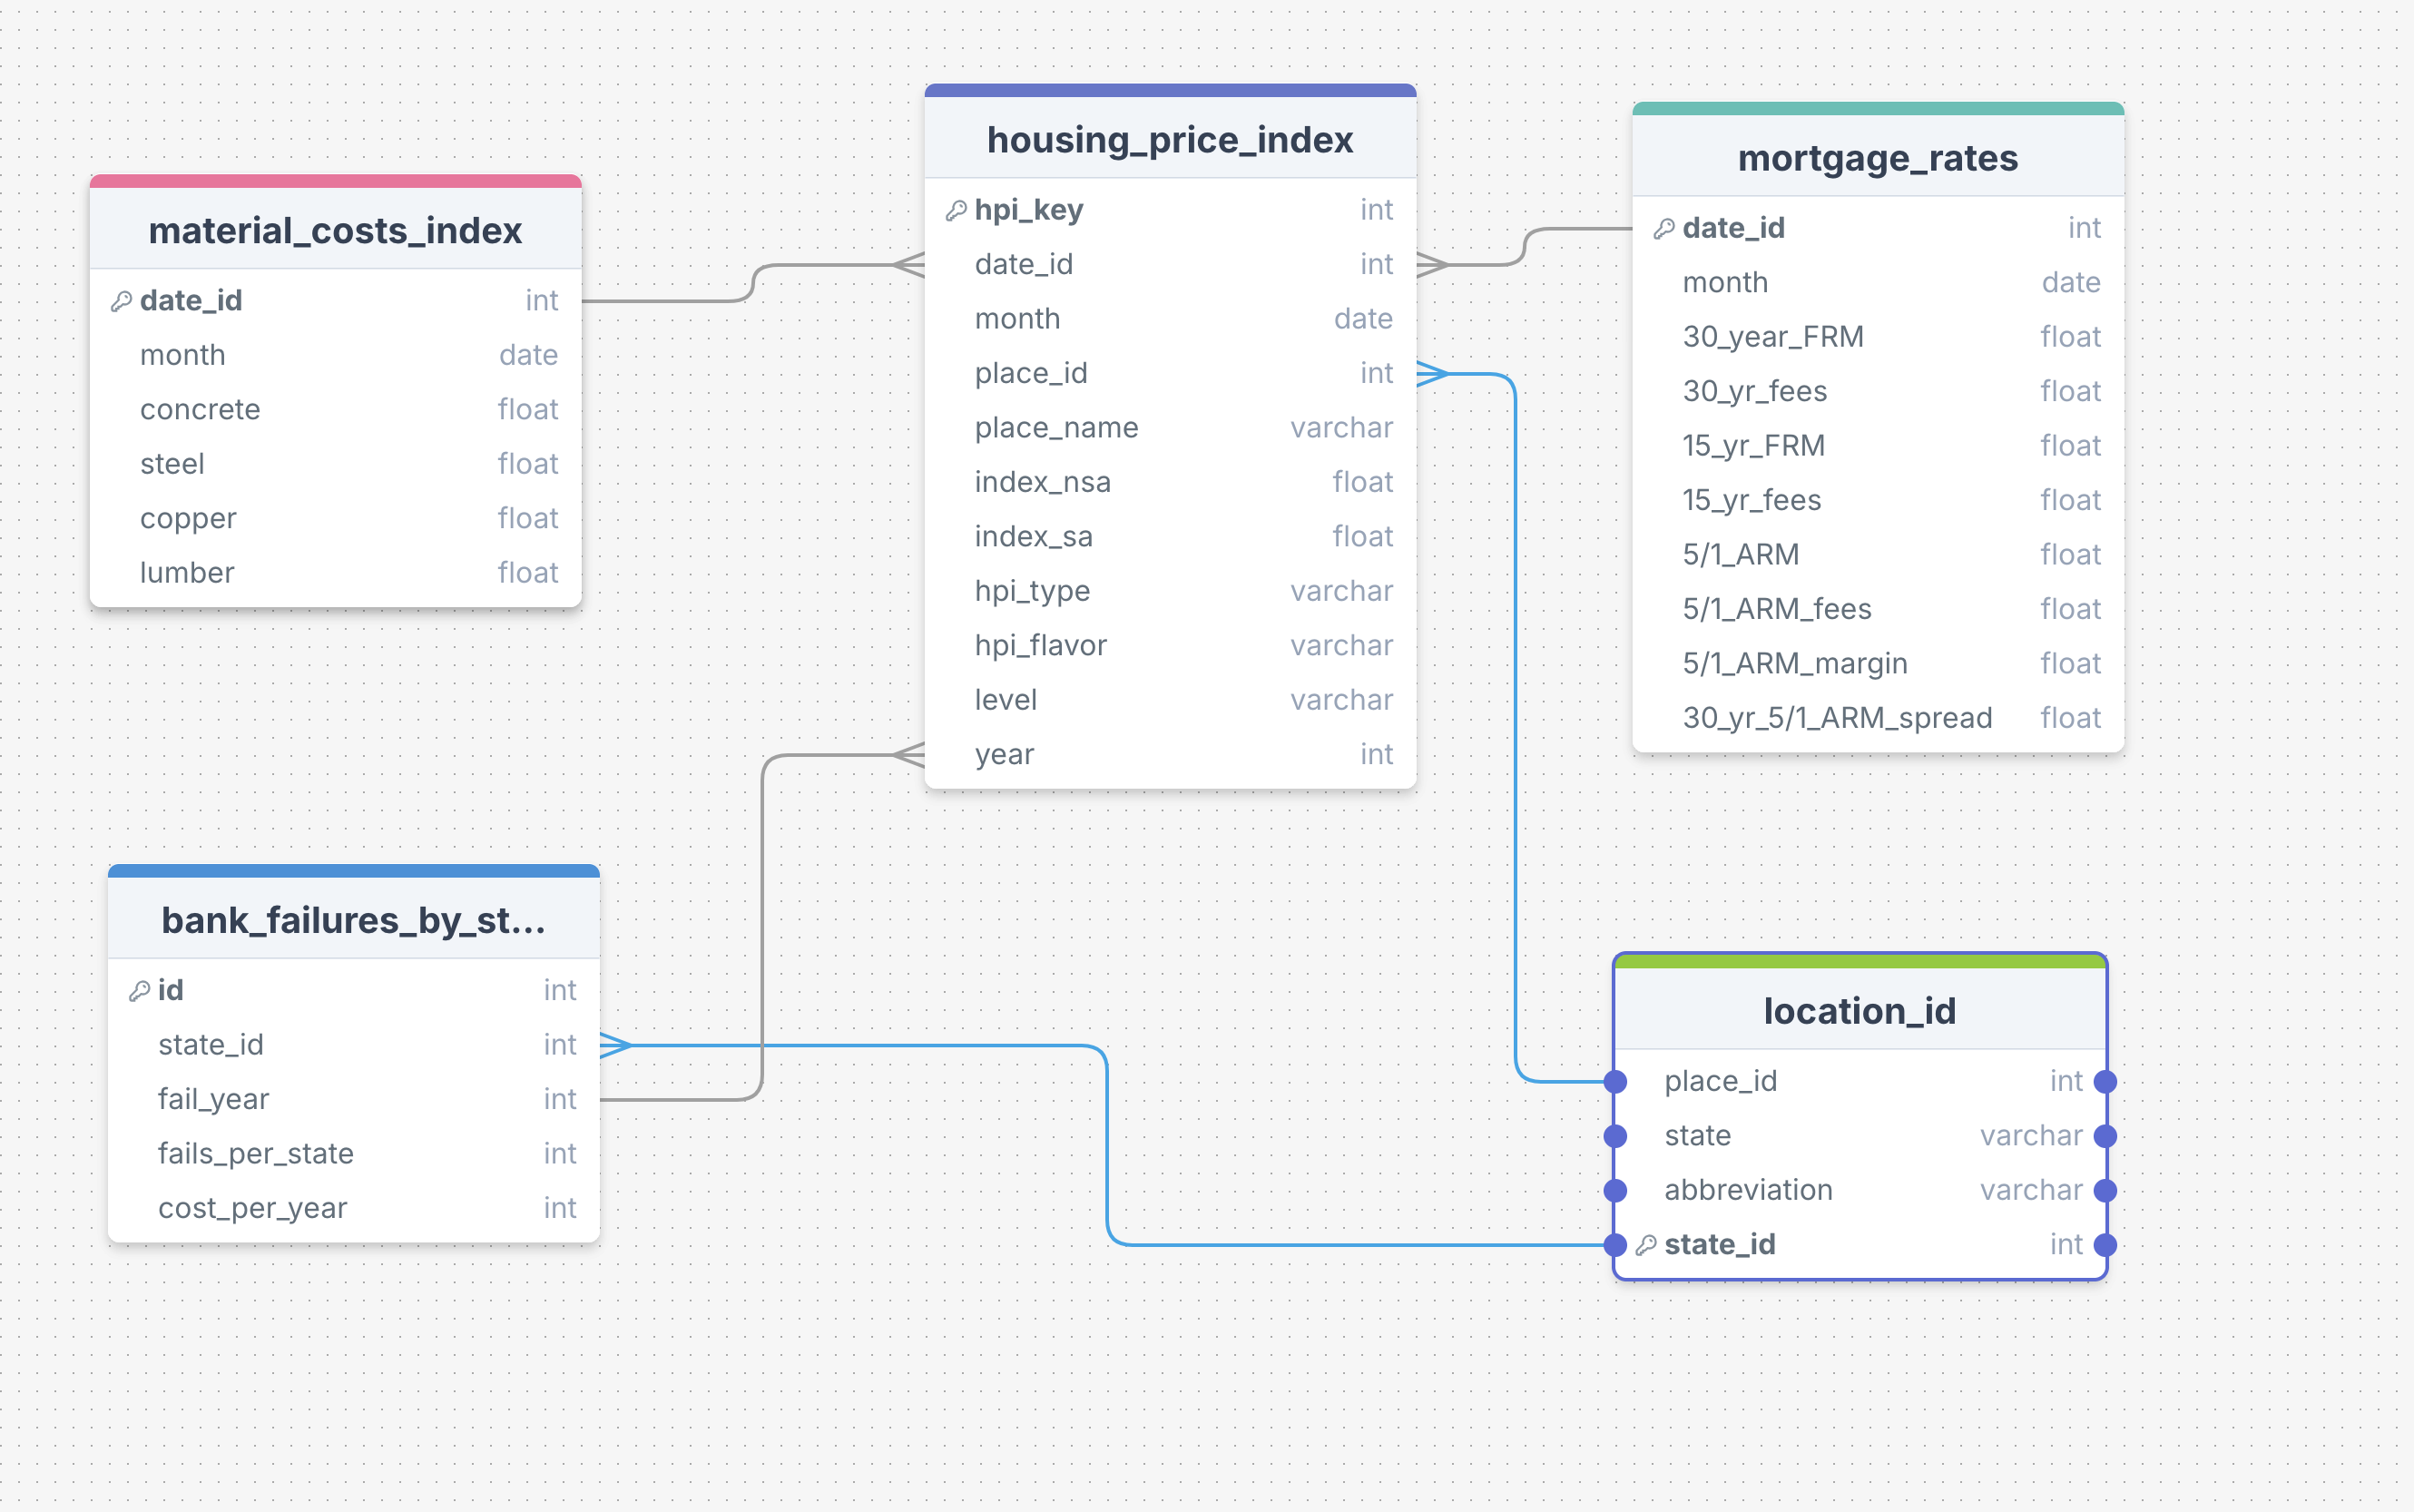

#Load


##Helper Functions


In [406]:
# create helper functions
import psycopg2

# create connection variables
AWS_host_name = "ista322database01.ctq0cmc66azq.us-east-2.rds.amazonaws.com"
AWS_dbname = "ista322database01"
AWS_user_name = "vcasilio"
AWS_password = "Ralphie101!!"

#define cursor function
def get_conn_cur():
                              # make connection
  conn = psycopg2.connect(
    host=AWS_host_name,
    database=AWS_dbname,
    user=AWS_user_name,
    password=AWS_password,
    port='5432')

  cur = conn.cursor()   # make cursor

  return(conn, cur)   # return connection and cursor

#define get_table_names function
def get_table_names():
  conn, cur = get_conn_cur() # get con and cursor using function above

  # table names query string
  tq = """SELECT table_name
          FROM information_schema.tables
          WHERE table_schema = 'public' """

  cur.execute(tq)           # execute query
  results = cur.fetchall()  # fetch results

  cur.close()   # close cursor
  conn.close()  # close connection

  return(results)

#define get_column_names function
def get_column_names(query_table): # argument is name of table to retrieve col names
  conn, cur = get_conn_cur()      # get connection and cursor

  #column names query string
  cnq = """SELECT column_name
           FROM information_schema.columns
           WHERE table_name = '%s' """ %query_table

  cur.execute(cnq) # execute query
  results = cur.fetchall() # fetch results

  cur.close()   # close cursor
  conn.close()  # close connection

  names = [desc[0] for desc in cur.description]  # create list of column names

  cur.close()   # close cursor
  conn.close()  # close connection

  return(names, results) # return names and data

#define run_query function
def run_query(qs):
  conn,cur = get_conn_cur() # get connection and cursor

  cur.execute(qs) # execute query string

  results = cur.fetchall() # fecth data and store it

  column_names = [desc[0] for desc in cur.description]

  cur.close() # close cursor
  conn.close() # close connection

  return(column_names, results) # return column names and results


# make function to return equivolent of pandas .head()
def sql_head(table):    # arg is name of table to return header for
  conn, cur = get_conn_cur()      # get connection and cursor

  thq = """SELECT * FROM %s LIMIT 5""" %table   # query string

  cur.execute(thq) # execute query string
  data = cur.fetchall() #fetch results
  column_names = [desc[0] for desc in cur.description] #variable to store column names

  cur.close()   # close cursor
  conn.close()  # close connection

  df = df = pd.DataFrame(data = data, columns = column_names)

  return(df)

#define drop_tables function
def drop_table(table):  #table is name of table to be dropped
  conn, cur = get_conn_cur()    # get connection and cursor
  tdq = """DROP TABLE IF EXISTS %s CASCADE;""" %table   # query string
  cur.execute(tdq)      # execute query string
  conn.commit()     # finalize


In [407]:
get_table_names()

[('weekly_stats',),
 ('character_information',),
 ('casetype',),
 ('house_information',),
 ('character_occurance',),
 ('rollup',),
 ('housing_price_index',),
 ('regional_information',),
 ('states',),
 ('mortgage_rates',),
 ('material_costs_index',),
 ('death_data',),
 ('cases',),
 ('bank_failures_by_state',),
 ('location_id',),
 ('judges',),
 ('battle_data',)]

## Load HPI

In [408]:
hpi_monthly.head()
hpi_monthly.dtypes

,hpi_key,date_id,month,place_id,place_name,index_nsa,index_sa,hpi_type,hpi_flavor,level,year
0,1,1,1991-01-01,DV_ENC,East North Central Division,100.00,100.00,traditional,purchase-only,USA or Census Division,1991
1,2,2,1991-02-01,DV_ENC,East North Central Division,100.87,100.87,traditional,purchase-only,USA or Census Division,1991
2,3,3,1991-03-01,DV_ENC,East North Central Division,101.32,100.90,traditional,purchase-only,USA or Census Division,1991
3,4,4,1991-04-01,DV_ENC,East North Central Division,101.73,100.97,traditional,purchase-only,USA or Census Division,1991
4,5,5,1991-05-01,DV_ENC,East North Central Division,102.32,101.30,traditional,purchase-only,USA or Census Division,1991


,0
hpi_key,int64
date_id,int64
month,datetime64[ns]
place_id,object
place_name,object
index_nsa,float64
index_sa,float64
hpi_type,object
hpi_flavor,object
level,object


In [409]:
#drop table if necessay
drop_table('housing_price_index')

In [410]:
#create housing_price_index table
conn, cur = get_conn_cur()
tq = """CREATE TABLE housing_price_index (
     hpi_key INTEGER PRIMARY KEY,
     date_id INTEGER,
     month DATE,
     place_id VARCHAR(225),
     place_name VARCHAR(225),
     index_nsa FLOAT,
     index_sa FLOAT,
     hpi_type VARCHAR(225),
     hpi_flavor VARCHAR(225),
     level VARCHAR(225),
     year INTEGER
     );"""
cur.execute(tq)
conn.commit()
get_table_names()

[('weekly_stats',),
 ('character_information',),
 ('casetype',),
 ('housing_price_index',),
 ('house_information',),
 ('character_occurance',),
 ('rollup',),
 ('regional_information',),
 ('states',),
 ('mortgage_rates',),
 ('material_costs_index',),
 ('death_data',),
 ('cases',),
 ('bank_failures_by_state',),
 ('location_id',),
 ('judges',),
 ('battle_data',)]

In [411]:
get_column_names('housing_price_index')

(['column_name'],
 [('year',),
  ('date_id',),
  ('month',),
  ('index_nsa',),
  ('index_sa',),
  ('hpi_key',),
  ('level',),
  ('hpi_type',),
  ('place_id',),
  ('place_name',),
  ('hpi_flavor',)])

In [412]:
#push data into housing_price_index
#make tuple
hpi_tups = [tuple(x) for x in hpi_monthly.to_numpy()]
hpi_iq = """INSERT INTO housing_price_index(hpi_key,date_id,month,place_id,place_name,index_nsa,index_sa,hpi_type,hpi_flavor,level,year) VALUES(%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s);"""
hpi_tups[2]

(3,
 3,
 Timestamp('1991-03-01 00:00:00'),
 'DV_ENC',
 'East North Central Division',
 101.32,
 100.9,
 'traditional',
 'purchase-only',
 'USA or Census Division',
 1991)

In [413]:
#push data
conn, cur = get_conn_cur()
cur.executemany(hpi_iq, hpi_tups)
conn.commit()

In [414]:
sql_head('housing_price_index')

,hpi_key,date_id,month,place_id,place_name,index_nsa,index_sa,hpi_type,hpi_flavor,level,year
0,1,1,1991-01-01,DV_ENC,East North Central Division,100.00,100.00,traditional,purchase-only,USA or Census Division,1991
1,2,2,1991-02-01,DV_ENC,East North Central Division,100.87,100.87,traditional,purchase-only,USA or Census Division,1991
2,3,3,1991-03-01,DV_ENC,East North Central Division,101.32,100.90,traditional,purchase-only,USA or Census Division,1991
3,4,4,1991-04-01,DV_ENC,East North Central Division,101.73,100.97,traditional,purchase-only,USA or Census Division,1991
4,5,5,1991-05-01,DV_ENC,East North Central Division,102.32,101.30,traditional,purchase-only,USA or Census Division,1991


##Load Mortgage Rates

In [415]:
#drop table if necessay
drop_table('mortgage_rates')

In [416]:
#create housing_price_index table
conn, cur = get_conn_cur()
tq = """CREATE TABLE mortgage_rates (
     date_id INTEGER PRIMARY KEY,
     month DATE,
     thirty_year_FRM FLOAT,
     thirty_year_fees FLOAT,
     fifteen_year_FRM FLOAT,
     fifteen_year_fees FLOAT,
     five_one_ARM FLOAT,
     five_one_ARM_fees FLOAT,
     five_one_ARM_margin FLOAT,
     thirty_yr_to_five_one_ARM_spread FLOAT
     );"""
cur.execute(tq)
conn.commit()
get_table_names()

[('weekly_stats',),
 ('character_information',),
 ('casetype',),
 ('housing_price_index',),
 ('house_information',),
 ('character_occurance',),
 ('rollup',),
 ('mortgage_rates',),
 ('regional_information',),
 ('states',),
 ('material_costs_index',),
 ('death_data',),
 ('cases',),
 ('bank_failures_by_state',),
 ('location_id',),
 ('judges',),
 ('battle_data',)]

In [417]:
get_column_names('mortgage_rates')

(['column_name'],
 [('date_id',),
  ('month',),
  ('thirty_year_frm',),
  ('thirty_year_fees',),
  ('fifteen_year_frm',),
  ('fifteen_year_fees',),
  ('five_one_arm',),
  ('five_one_arm_fees',),
  ('five_one_arm_margin',),
  ('thirty_yr_to_five_one_arm_spread',)])

In [418]:
#push data into mortgage_rates
#make tuple
rates_tups = [tuple(x) for x in rates_monthly.to_numpy()]
rates_iq = """INSERT INTO mortgage_rates(date_id,month,thirty_year_frm,thirty_year_fees,fifteen_year_frm,fifteen_year_fees,five_one_arm,five_one_arm_fees,five_one_arm_margin,thirty_yr_to_five_one_arm_spread) VALUES(%s, %s, %s, %s, %s, %s, %s, %s, %s, %s);"""
rates_tups[2]

(3,
 Timestamp('1991-03-01 00:00:00'),
 9.5,
 2.08,
 None,
 None,
 None,
 None,
 None,
 None)

In [419]:
#push data
conn, cur = get_conn_cur()
cur.executemany(rates_iq, rates_tups)
conn.commit()

In [420]:
sql_head('mortgage_rates')

,date_id,month,thirty_year_frm,thirty_year_fees,fifteen_year_frm,fifteen_year_fees,five_one_arm,five_one_arm_fees,five_one_arm_margin,thirty_yr_to_five_one_arm_spread
0,1,1991-01-01,9.64,2.05,None,None,None,None,None,None
1,2,1991-02-01,9.36,2.00,None,None,None,None,None,None
2,3,1991-03-01,9.50,2.08,None,None,None,None,None,None
3,4,1991-04-01,9.49,2.02,None,None,None,None,None,None
4,5,1991-05-01,9.47,1.96,None,None,None,None,None,None


##Load Materials Index

In [421]:
material_costs_index.head()

,date_id,month,concrete,steel,copper,lumber
0,1,1991-01-01,100.0,100.0,100.0,100.0
1,2,1991-02-01,100.2,99.6,97.9,99.7
2,3,1991-03-01,100.6,99.2,98.2,100.2
3,4,1991-04-01,100.3,98.6,97.7,101.3
4,5,1991-05-01,100.3,98.0,95.1,103.7


In [422]:
#drop table if necessary
drop_table('material_costs_index')

In [423]:
#create material_costs_index table
conn, cur = get_conn_cur()
tq = """CREATE TABLE material_costs_index (
     date_id INTEGER PRIMARY KEY,
     month DATE,
     concrete FLOAT,
     steel FLOAT,
     copper FLOAT,
     lumber FLOAT
     );"""
cur.execute(tq)
conn.commit()
get_table_names()

[('weekly_stats',),
 ('character_information',),
 ('casetype',),
 ('housing_price_index',),
 ('house_information',),
 ('character_occurance',),
 ('rollup',),
 ('mortgage_rates',),
 ('regional_information',),
 ('states',),
 ('material_costs_index',),
 ('death_data',),
 ('cases',),
 ('bank_failures_by_state',),
 ('location_id',),
 ('judges',),
 ('battle_data',)]

In [424]:
get_column_names('material_costs_index')

(['column_name'],
 [('date_id',),
  ('month',),
  ('concrete',),
  ('steel',),
  ('copper',),
  ('lumber',)])

In [425]:
#push data into material_costs_index
#make tuple
material_tups = [tuple(x) for x in material_costs_index.to_numpy()]
material_iq = """INSERT INTO material_costs_index(date_id,month,concrete,steel,copper,lumber) VALUES(%s, %s, %s, %s, %s, %s);"""
material_tups[2]

(3, Timestamp('1991-03-01 00:00:00'), 100.6, 99.2, 98.2, 100.2)

In [426]:
#push data
conn, cur = get_conn_cur()
cur.executemany(material_iq, material_tups)
conn.commit()

In [427]:
sql_head('material_costs_index')

,date_id,month,concrete,steel,copper,lumber
0,1,1991-01-01,100.0,100.0,100.0,100.0
1,2,1991-02-01,100.2,99.6,97.9,99.7
2,3,1991-03-01,100.6,99.2,98.2,100.2
3,4,1991-04-01,100.3,98.6,97.7,101.3
4,5,1991-05-01,100.3,98.0,95.1,103.7


##Load Bank Failures

In [428]:
#drop table if necessary
drop_table('bank_failures_by_state')

In [429]:
#create bank_failures_by_state table
conn, cur = get_conn_cur()
tq = """CREATE TABLE bank_failures_by_state (
     id INTEGER PRIMARY KEY,
     state_id INTEGER,
     fail_year INTEGER,
     fails_per_state INTEGER,
     cost_per_year_in_thousands BIGINT
     );"""
cur.execute(tq)
conn.commit()
get_table_names()

[('weekly_stats',),
 ('character_information',),
 ('casetype',),
 ('housing_price_index',),
 ('house_information',),
 ('character_occurance',),
 ('rollup',),
 ('mortgage_rates',),
 ('regional_information',),
 ('states',),
 ('material_costs_index',),
 ('bank_failures_by_state',),
 ('death_data',),
 ('cases',),
 ('location_id',),
 ('judges',),
 ('battle_data',)]

In [430]:
#get col names
get_column_names('bank_failures_by_state')

(['column_name'],
 [('id',),
  ('state_id',),
  ('fail_year',),
  ('fails_per_state',),
  ('cost_per_year_in_thousands',)])

In [431]:
#push data into bak_failures
#make tuple
from psycopg2.extensions import register_adapter, AsIs
def adapt_numpy_int64(numpy_int64):
  return AsIs(numpy_int64)
register_adapter(np.int64, adapt_numpy_int64)
fails_tups = [tuple(x) for x in state_failures.to_numpy()]
fails_iq = """INSERT INTO bank_failures_by_state(id,state_id,fail_year,fails_per_state,cost_per_year_in_thousands) VALUES(%s, %s, %s, %s, %s);"""
fails_tups[2]

(3, 4, 1991, 2, 17218)

In [432]:
#push data
conn, cur = get_conn_cur()
cur.executemany(fails_iq, fails_tups)
conn.commit()

In [433]:
sql_head('bank_failures_by_state')

,id,state_id,fail_year,fails_per_state,cost_per_year_in_thousands
0,1,1,1991,2,88671
1,2,3,1991,2,18558
2,3,4,1991,2,17218
3,4,5,1991,21,2192082
4,5,6,1991,4,8584


##Load Location Id

In [434]:
state_id.head()

,state_id,state,abbreviation,region_id
0,1,Alabama,AL,DV_ESC
1,2,Alaska,AK,DV_PAC
2,3,Arizona,AZ,DV_MT
3,4,Arkansas,AR,DV_WSC
4,5,California,CA,DV_PAC


In [435]:
#drop table if necessary
drop_table('location_id')

In [436]:
#create location_id table
conn, cur = get_conn_cur()
tq = """CREATE TABLE location_id (
     state_id INTEGER PRIMARY KEY,
     state VARCHAR(225),
     abbreviation VARCHAR(225),
     place_id VARCHAR(225)
     );"""
cur.execute(tq)
conn.commit()
get_table_names()

[('weekly_stats',),
 ('character_information',),
 ('casetype',),
 ('housing_price_index',),
 ('house_information',),
 ('character_occurance',),
 ('rollup',),
 ('mortgage_rates',),
 ('regional_information',),
 ('states',),
 ('material_costs_index',),
 ('bank_failures_by_state',),
 ('death_data',),
 ('cases',),
 ('location_id',),
 ('judges',),
 ('battle_data',)]

In [437]:
get_column_names('location_id')

(['column_name'],
 [('state_id',), ('state',), ('abbreviation',), ('place_id',)])

In [438]:
#push data into location_id
#make tuple
location_tups = [tuple(x) for x in state_id.to_numpy()]
location_iq = """INSERT INTO location_id(state_id,state,abbreviation,place_id) VALUES(%s, %s, %s, %s);"""
location_tups[2]

(3, 'Arizona', 'AZ', 'DV_MT')

In [439]:
#push data
conn, cur = get_conn_cur()
cur.executemany(location_iq, location_tups)
conn.commit()

In [440]:
sql_head('location_id')

,state_id,state,abbreviation,place_id
0,1,Alabama,AL,DV_ESC
1,2,Alaska,AK,DV_PAC
2,3,Arizona,AZ,DV_MT
3,4,Arkansas,AR,DV_WSC
4,5,California,CA,DV_PAC


#Queries

##Basic queries to test RDB tables

In [441]:
#find average non-seasionally adjusted index average from HPI table
bq1 = """SELECT year, AVG(index_nsa) FROM housing_price_index GROUP BY year LIMIT 5;"""
run_query(bq1)

(['year', 'avg'],
 [(2012, 187.96825000000004),
  (2018, 262.2294166666667),
  (2024, 435.53274999999996),
  (1995, 113.62841666666664),
  (2021, 348.2349166666666)])

In [442]:
#find highest and lowest monthly mortgage rates of 15 year and 30 year from mortgage rates
bq2 = """SELECT MAX(thirty_year_frm), MAX(fifteen_year_frm), MIN(thirty_year_frm), MIN(fifteen_year_frm) FROM mortgage_rates;"""
run_query(bq2)

(['max', 'max', 'min', 'min'], [(9.64, 8.8, 2.68, 2.14)])

In [443]:
#find state_id with highest number of bank failures in 2009
bq3 = """SELECT state_id, fails_per_state FROM bank_failures_by_state WHERE fail_year = 2009 ORDER BY fails_per_state DESC LIMIT 1;"""
run_query(bq3)

(['state_id', 'fails_per_state'], [(11, 25)])

In [444]:
#find highest index values for construction materials
bq4 = """SELECT MAX(concrete), MAX(steel), MAX(copper), MAX(lumber) FROM material_costs_index;"""
run_query(bq4)

(['max', 'max', 'max', 'max'], [(341.0, 400.8, 379.8, 292.2)])

## Queries between tables

In [445]:
#Find 15 year and 30 year mortgage rate where concrete index was as its lowest
q1 = """SELECT fifteen_year_frm, thirty_year_frm, month
        FROM mortgage_rates
        WHERE date_id = (SELECT MIN(concrete) FROM material_costs_index)
        ;"""
run_query(q1)

(['fifteen_year_frm', 'thirty_year_frm', 'month'],
 [(6.53, 6.92, datetime.date(1999, 4, 1))])

In [446]:
#Find state_id and fails_per_state from bank_failures in region with lowest housing price index in 2009
q2 = """SELECT fails_per_state, state_id FROM bank_failures_by_state WHERE fail_year = 2009 AND state_id IN (
          SELECT state_id FROM location_id
          WHERE place_id = (
            SELECT place_id
            FROM housing_price_index
            WHERE year = 2009
            ORDER BY index_nsa ASC
            LIMIT 1))
        ;"""
run_query(q2)

(['fails_per_state', 'state_id'],
 [(21, 14), (1, 15), (2, 30), (4, 35), (1, 50)])

In [447]:
#Find 15 year FRM rate from month with highest seasonally adjusted hpi
q3 = """SELECT fifteen_year_frm, date_id FROM mortgage_rates WHERE date_id IN (
          SELECT date_id FROM housing_price_index ORDER BY index_sa DESC LIMIT 1)
        ;"""
run_query(q3)

(['fifteen_year_frm', 'date_id'], [(6.16, 409)])

In [448]:
#find avg of all materials index and month from month with highest sesonally adjusted HPI
q4 = """SELECT (concrete + steel + copper + lumber) / 4 AS ave_material_index, month FROM material_costs_index WHERE date_id = (
          SELECT date_id FROM housing_price_index ORDER BY index_sa DESC LIMIT 1)
        ;"""
run_query(q4)

(['ave_material_index', 'month'], [(288.375, datetime.date(2025, 1, 1))])